# Debug File Cleanup Script

In [ ]:
# ==============================================================================
# Debug File Cleanup Script for Ship-Aware U-Net Training
# ==============================================================================

import os
import glob

def cleanup_debug_files(images_dir):
    """
    Remove debug visualization files from the images directory.
    These files don't have corresponding masks and cause training errors.
    """
    print("Cleaning up debug files...")

    # Find all debug files
    debug_pattern = os.path.join(images_dir, "debug_*.jpg")
    debug_files = glob.glob(debug_pattern)

    if not debug_files:
        print("No debug files found to clean up.")
        return

    print(f"Found {len(debug_files)} debug files to remove:")

    for debug_file in debug_files:
        try:
            print(f"  Removing: {os.path.basename(debug_file)}")
            os.remove(debug_file)
        except OSError as e:
            print(f"  Error removing {debug_file}: {e}")

    print(f"Cleanup complete. Removed {len(debug_files)} debug files.")

def verify_dataset_integrity(images_dir, masks_dir):
    """
    Verify that all images have corresponding masks.
    """
    print("Verifying dataset integrity...")

    # Get all image files (excluding debug files)
    image_files = [f for f in os.listdir(images_dir)
                   if f.endswith('.jpg') and not f.startswith('debug_')]

    missing_masks = []
    valid_pairs = 0

    for img_file in image_files:
        mask_file = img_file.replace('.jpg', '.png')
        mask_path = os.path.join(masks_dir, mask_file)

        if os.path.exists(mask_path):
            valid_pairs += 1
        else:
            missing_masks.append(mask_file)

    print(f"Dataset verification results:")
    print(f"  Total images: {len(image_files)}")
    print(f"  Valid image-mask pairs: {valid_pairs}")
    print(f"  Missing masks: {len(missing_masks)}")

    if missing_masks:
        print(f"  Files missing masks:")
        for mask in missing_masks[:10]:  # Show first 10
            print(f"    - {mask}")
        if len(missing_masks) > 10:
            print(f"    ... and {len(missing_masks) - 10} more")

    return valid_pairs, missing_masks

def main():
    """
    Run cleanup and verification for ship-aware training data.
    """
    # Update these paths based on your setup
    LOCAL_IMAGES_PATH = '/content/processed_unet_ship_aware/images'
    LOCAL_MASKS_PATH = '/content/processed_unet_ship_aware/masks'

    print("Ship-Aware Dataset Cleanup and Verification")
    print("=" * 50)

    # Check if directories exist
    if not os.path.exists(LOCAL_IMAGES_PATH):
        print(f"Error: Images directory not found: {LOCAL_IMAGES_PATH}")
        return

    if not os.path.exists(LOCAL_MASKS_PATH):
        print(f"Error: Masks directory not found: {LOCAL_MASKS_PATH}")
        return

    # Clean up debug files
    cleanup_debug_files(LOCAL_IMAGES_PATH)
    print()

    # Verify dataset integrity
    valid_pairs, missing_masks = verify_dataset_integrity(LOCAL_IMAGES_PATH, LOCAL_MASKS_PATH)

    if missing_masks:
        print(f"\n⚠️  Warning: {len(missing_masks)} images don't have corresponding masks.")
        print("This might indicate an issue with the preprocessing step.")
    else:
        print(f"\n✅ Dataset integrity verified: {valid_pairs} valid image-mask pairs.")

    print("\nDataset is ready for training!")

if __name__ == "__main__":
    main()


Ship-Aware Dataset Cleanup and Verification
Error: Images directory not found: /content/processed_unet_ship_aware/images


# U-Net Ship-Aware Color-Based

Using device: cuda
GPU Name: Tesla T4
Mounted at /content/drive
Google Drive processed data path: /content/drive/My Drive/SMD_Dataset/processed_unet_ship_aware
Google Drive model save path: /content/drive/My Drive/SMD_Dataset/models
Local runtime data path: /content/processed_unet_ship_aware
Processed data found on Google Drive.
Copying data from '/content/drive/My Drive/SMD_Dataset/processed_unet_ship_aware' to local runtime '/content/processed_unet_ship_aware'...
Data successfully copied to local runtime.

Dataset loaded from local runtime and split by video.
Total videos: 37 -> Train: 29, Val: 4, Test: 4
Total frames: 17222 -> Train: 13911, Val: 1561, Test: 1750


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 179MB/s]
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(



--- Starting Ship-Aware U-Net Training with Regularization & Early Stopping ---
Epoch 1/50 -> Train Loss: 0.1202, Val Loss: 0.0353, Val IoU: 0.9666
  -> Model saved with new best validation IoU: 0.9666
Epoch 2/50 -> Train Loss: 0.0229, Val Loss: 0.1205, Val IoU: 0.9188
Epoch 3/50 -> Train Loss: 0.0187, Val Loss: 0.0772, Val IoU: 0.9443
Epoch 4/50 -> Train Loss: 0.0171, Val Loss: 0.0871, Val IoU: 0.9407
Epoch 5/50 -> Train Loss: 0.0164, Val Loss: 0.0680, Val IoU: 0.9478
Epoch 6/50 -> Train Loss: 0.0159, Val Loss: 0.1574, Val IoU: 0.9215
Epoch 7/50 -> Train Loss: 0.0156, Val Loss: 0.1426, Val IoU: 0.9332
Epoch 8/50 -> Train Loss: 0.0145, Val Loss: 0.1173, Val IoU: 0.9379
Epoch 9/50 -> Train Loss: 0.0142, Val Loss: 0.1342, Val IoU: 0.9293
Epoch 10/50 -> Train Loss: 0.0140, Val Loss: 0.1221, Val IoU: 0.9322
Epoch 11/50 -> Train Loss: 0.0139, Val Loss: 0.1136, Val IoU: 0.9325
--- Early stopping triggered after 10 epochs with no improvement. ---
--- Finished Training. Best validation IoU: 0

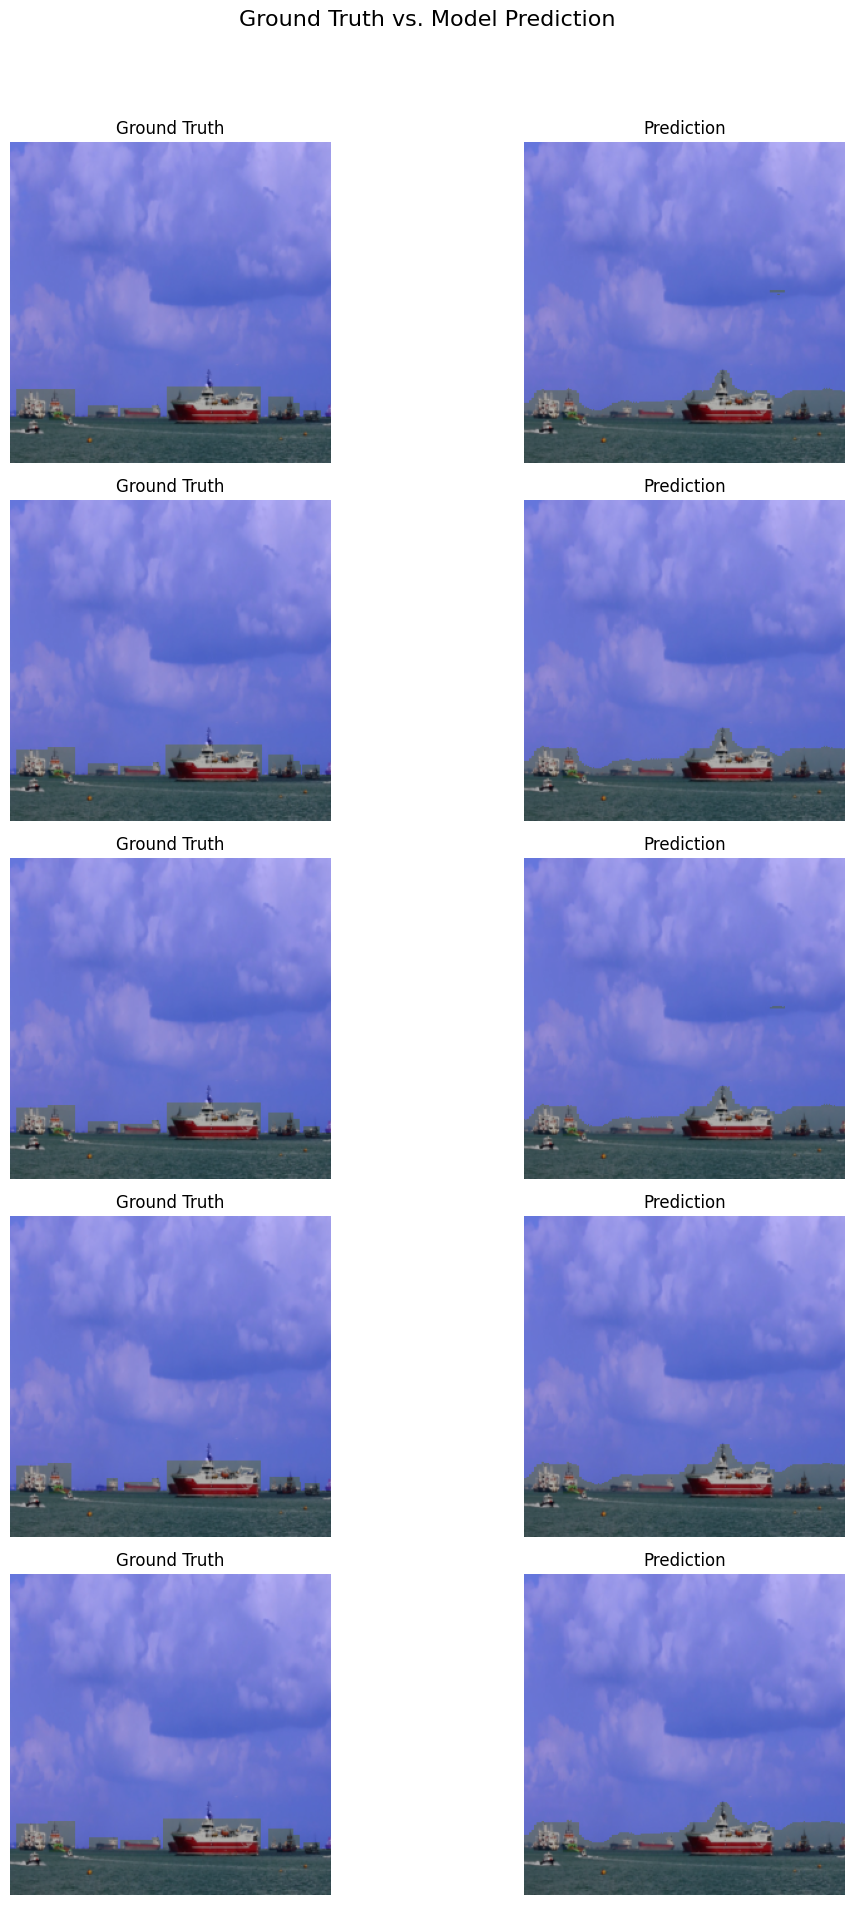

In [ ]:
# ==============================================================================
# Step 1: Setup and Environment - Ship-Aware U-Net Training
# ==============================================================================
# Install necessary libraries. SciPy is needed for loading .mat files.
!pip install opencv-python-headless scipy

"""
Ship-Aware U-Net Training for Maritime Horizon Detection

This training script creates ship-aware ground truth masks where:
- Ships and maritime objects are correctly labeled as "non-sky"
- Only pure sky regions are labeled as "sky"
- Uses computer vision ship detection to improve ground truth quality

Expected improved results:
- Ships will be correctly segmented as non-sky objects
- Better semantic understanding of maritime scenes
- Reduced false positives in sky classification

Previous results (with basic geometric masks):
Epoch 1/50 -> Train Loss: 0.0971, Val Loss: 0.0366, Val IoU: 0.9812
  -> Model saved with new best validation IoU: 0.9812
Epoch 2/50 -> Train Loss: 0.0070, Val Loss: 0.0082, Val IoU: 0.9934
  -> Model saved with new best validation IoU: 0.9934
! still reaches the best model after 2 epochs, shows overfitting, thats a problem.
! needs a better, more varied dataset to train on
Epoch 3/50 -> Train Loss: 0.0049, Val Loss: 0.0100, Val IoU: 0.9923
Epoch 4/50 -> Train Loss: 0.0034, Val Loss: 0.0090, Val IoU: 0.9930
Epoch 5/50 -> Train Loss: 0.0029, Val Loss: 0.0093, Val IoU: 0.9934

Expected with ship-aware training:
- Lower initial IoU (as ship regions are now correctly labeled)
- Better generalization to real maritime scenes
- Ships correctly classified as non-sky
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau # --- CHANGE: Added for learning rate scheduling
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
import torchvision.models as models
from torchvision.models.resnet import ResNet18_Weights

import numpy as np
import cv2
import os
from PIL import Image
import matplotlib.pyplot as plt
import math
from google.colab import drive
from scipy.io import loadmat
import collections
import random

# Check if a GPU is available and set the device accordingly.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

# ==============================================================================
# Step 2: Connect to Google Drive and Set Up Paths
# ==============================================================================
# This will mount your Google Drive to the Colab environment.
drive.mount('/content/drive')

# --- IMPORTANT: SET YOUR PATHS HERE ---
BASE_DRIVE_PATH = '/content/drive/My Drive/SMD_Dataset'

# --- FIX: ADD THESE TWO LINES ---
SMD_VIDEOS_PATH = os.path.join(BASE_DRIVE_PATH, 'VIS_Onshore/Videos')
SMD_GT_PATH = os.path.join(BASE_DRIVE_PATH, 'VIS_Onshore/HorizonGT')
GDRIVE_MODEL_SAVE_PATH = os.path.join(BASE_DRIVE_PATH, 'models')
GDRIVE_PROCESSED_IMAGES_PATH = os.path.join(BASE_DRIVE_PATH, 'processed_unet_ship_aware/images')
GDRIVE_PROCESSED_MASKS_PATH = os.path.join(BASE_DRIVE_PATH, 'processed_unet_ship_aware/masks')

# --- The rest of your path definitions follow ---
GDRIVE_PROCESSED_DATA_PATH = os.path.join(BASE_DRIVE_PATH, 'processed_unet_ship_aware')
os.makedirs(GDRIVE_MODEL_SAVE_PATH, exist_ok=True)


# This is where the data will be stored LOCALLY on the Colab machine for fast access.
# --- CHANGE: Renamed local path for ship-aware data ---
LOCAL_DATA_PATH = '/content/processed_unet_ship_aware'
LOCAL_IMAGES_PATH = os.path.join(LOCAL_DATA_PATH, 'images')
LOCAL_MASKS_PATH = os.path.join(LOCAL_DATA_PATH, 'masks')

os.makedirs(GDRIVE_PROCESSED_IMAGES_PATH, exist_ok=True)
os.makedirs(GDRIVE_PROCESSED_MASKS_PATH, exist_ok=True)

print(f"Google Drive processed data path: {GDRIVE_PROCESSED_DATA_PATH}")
print(f"Google Drive model save path: {GDRIVE_MODEL_SAVE_PATH}")
print(f"Local runtime data path: {LOCAL_DATA_PATH}")

# ==============================================================================
# Step 3: Ship-Aware Dataset Generation Functions
# ==============================================================================
def detect_ships_in_frame(frame, horizon_y):
    """
    Detect ships and objects that should be classified as non-sky.
    Returns a mask where ships are marked.
    """
    h, w = frame.shape[:2]
    ship_mask = np.zeros((h, w), dtype=np.uint8)

    # Convert to different color spaces
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    # Method 1: Detect dark objects (ship hulls) above horizon
    # Look for objects in the region above water but below sky
    search_top = max(0, horizon_y - 100)  # Search above horizon
    search_bottom = min(h, horizon_y + 20)  # Include some water region

    roi_gray = gray[search_top:search_bottom, :]

    if roi_gray.size > 0:
        # Adaptive threshold to find dark objects
        thresh = cv2.adaptiveThreshold(roi_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                     cv2.THRESH_BINARY, 21, 10)

        # Find dark regions (ships are typically dark silhouettes)
        dark_regions = 255 - thresh

        # Morphological operations to clean up
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
        dark_regions = cv2.morphologyEx(dark_regions, cv2.MORPH_CLOSE, kernel)

        # Filter by size and aspect ratio
        contours, _ = cv2.findContours(dark_regions, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for contour in contours:
            area = cv2.contourArea(contour)
            if area > 200:  # Minimum ship size
                x, y, cw, ch = cv2.boundingRect(contour)
                # Check aspect ratio (ships are usually wider than tall)
                aspect_ratio = cw / ch if ch > 0 else 0
                if aspect_ratio > 1.2 and area > 500:
                    # Mark this region as ship in the full mask
                    cv2.rectangle(ship_mask,
                                (x, search_top + y),
                                (x + cw, search_top + y + ch), 255, -1)

    # Method 2: Color-based ship detection
    # Look for typical ship colors in the region above horizon
    search_region = hsv[search_top:search_bottom, :]

    if search_region.size > 0:
        # White/light structures (superstructures)
        white_lower = np.array([0, 0, 180])
        white_upper = np.array([180, 30, 255])
        white_mask = cv2.inRange(search_region, white_lower, white_upper)

        # Dark structures (hulls)
        dark_lower = np.array([0, 0, 0])
        dark_upper = np.array([180, 255, 80])
        dark_mask = cv2.inRange(search_region, dark_lower, dark_upper)

        # Combine color masks
        color_mask = cv2.bitwise_or(white_mask, dark_mask)

        # Clean up with morphological operations
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
        color_mask = cv2.morphologyEx(color_mask, cv2.MORPH_CLOSE, kernel)

        # Filter by contour size
        contours, _ = cv2.findContours(color_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for contour in contours:
            area = cv2.contourArea(contour)
            if area > 300:
                x, y, cw, ch = cv2.boundingRect(contour)
                # Mark this region as ship in the full mask
                ship_mask[search_top + y:search_top + y + ch, x:x + cw] = 255

    return ship_mask

def create_ship_aware_mask(frame, horizon_y):
    """
    Create a ship-aware ground truth mask that properly handles ships.

    Returns:
    - Class 0: Non-sky (water + ships + objects)
    - Class 1: Sky (pure sky region only)
    """
    h, w, _ = frame.shape

    # Create initial sky mask based on horizon line
    mask = np.zeros((h, w), dtype=np.uint8)

    # Everything above horizon is initially sky
    mask[:horizon_y, :] = 1

    # Detect ships and objects
    ship_mask = detect_ships_in_frame(frame, horizon_y)

    # Remove ships from sky region (set ships to non-sky class)
    mask[ship_mask == 255] = 0

    return mask

# ==============================================================================
# Step 4: Ship-Aware Preprocess Data for U-Net (Run only ONCE)
# ==============================================================================
def preprocess_smd_for_segmentation():
    """
    Extracts frames and creates ship-aware ground truth segmentation masks.
    Saves the output to your Google Drive.
    """
    print("Starting Ship-Aware SMD preprocessing for Segmentation...")
    video_files = sorted([f for f in os.listdir(SMD_VIDEOS_PATH) if f.endswith('.avi')])

    processed_count = 0
    total_videos = len(video_files)
    ships_detected_count = 0

    for i, video_file in enumerate(video_files):
        print(f"Processing video {i+1}/{total_videos}: {video_file}")
        video_name_without_ext = os.path.splitext(video_file)[0]
        gt_filename = f"{video_name_without_ext}_HorizonGT.mat"
        video_path = os.path.join(SMD_VIDEOS_PATH, video_file)
        gt_path = os.path.join(SMD_GT_PATH, gt_filename)

        if not os.path.exists(gt_path):
            continue

        gt_data = loadmat(gt_path)
        horizon_key = None
        for key in gt_data.keys():
            if not key.startswith('__'):
                horizon_key = key
                break

        if horizon_key is None:
            continue

        struct_array = gt_data[horizon_key]
        if struct_array.size == 0:
            continue

        cap = cv2.VideoCapture(video_path)
        frame_idx = 0

        while True:
            ret, frame = cap.read()
            if not ret:
                break
            if frame_idx >= struct_array.shape[1]:
                break

            try:
                # Extract horizon line parameters
                frame_struct = struct_array[0, frame_idx]
                x_point = float(frame_struct['X'][0,0])
                y_point = float(frame_struct['Y'][0,0])
                nx = float(frame_struct['Nx'][0,0])
                ny = float(frame_struct['Ny'][0,0])

                h, w, _ = frame.shape

                # Calculate horizon y-coordinate
                if abs(ny) < 1e-6:
                    horizon_y = int(y_point)
                else:
                    c = -(nx * x_point + ny * y_point)
                    horizon_y = int(-c / ny)

                # Clamp horizon to frame bounds
                horizon_y = max(0, min(h-1, horizon_y))

                # Create ship-aware mask
                mask = create_ship_aware_mask(frame, horizon_y)

                # Skip frames with invalid masks
                if mask.min() == mask.max():
                    frame_idx += 1
                    continue

                # Count ships detected
                ship_mask = detect_ships_in_frame(frame, horizon_y)
                if np.any(ship_mask == 255):
                    ships_detected_count += 1

            except (IndexError, TypeError, KeyError, ValueError) as e:
                frame_idx += 1
                continue

            # Save frame and mask
            frame_filename = f"{video_name_without_ext}_frame_{frame_idx:04d}.jpg"
            mask_filename = f"{video_name_without_ext}_frame_{frame_idx:04d}.png"

            cv2.imwrite(os.path.join(GDRIVE_PROCESSED_IMAGES_PATH, frame_filename), frame)
            cv2.imwrite(os.path.join(GDRIVE_PROCESSED_MASKS_PATH, mask_filename), mask)

            # Optional: Save debug visualization every 100 frames
            if processed_count % 100 == 0:
                vis_frame = frame.copy()
                overlay = np.zeros_like(frame)
                overlay[mask == 1] = [0, 0, 255]  # Sky in blue
                vis_frame = cv2.addWeighted(vis_frame, 0.7, overlay, 0.3, 0)
                cv2.line(vis_frame, (0, horizon_y), (w, horizon_y), (0, 255, 0), 2)

                debug_filename = f"debug_{video_name_without_ext}_frame_{frame_idx:04d}.jpg"
                cv2.imwrite(os.path.join(GDRIVE_PROCESSED_IMAGES_PATH, debug_filename), vis_frame)

            frame_idx += 1
            processed_count += 1

        cap.release()

    print(f"Ship-Aware preprocessing complete. Total frames processed: {processed_count}")
    print(f"Frames with ships detected: {ships_detected_count} ({ships_detected_count/processed_count*100:.1f}%)")

# Check if the processed folder on Drive is empty. If so, run preprocessing.
if not os.listdir(GDRIVE_PROCESSED_IMAGES_PATH):
    print("Processed data not found on Google Drive. Running preprocessing. This may take a while.")
    preprocess_smd_for_segmentation()
else:
    print("Processed data found on Google Drive.")

# --- Copy the entire folder from Drive to the local runtime ---
if not os.path.exists(LOCAL_DATA_PATH):
    print(f"Copying data from '{GDRIVE_PROCESSED_DATA_PATH}' to local runtime '{LOCAL_DATA_PATH}'...")
    !cp -r "{GDRIVE_PROCESSED_DATA_PATH}" "{LOCAL_DATA_PATH}"
    print("Data successfully copied to local runtime.")
else:
    print("Data already exists in local runtime. Skipping copy.")

# ==============================================================================
# Step 4: Create the Dataset with Aggressive Data Augmentation
# ==============================================================================
IMG_SIZE = (256, 256)
BATCH_SIZE = 16

class SegmentationDataset(Dataset):
    def __init__(self, image_files, masks_dir, size, is_train=False):
        self.image_files = image_files
        self.masks_dir = masks_dir
        self.size = size
        self.is_train = is_train

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = self.image_files[idx]
        img_name = os.path.basename(img_path)
        mask_name = img_name.replace('.jpg', '.png')
        mask_path = os.path.join(self.masks_dir, mask_name)

        # Check if mask file exists
        if not os.path.exists(mask_path):
            raise FileNotFoundError(f"Mask file not found: {mask_path}")

        try:
            image = Image.open(img_path).convert("RGB")
            mask = Image.open(mask_path).convert("L") # --- CHANGE: Ensure mask is single channel
        except Exception as e:
            raise IOError(f"Error loading image {img_path} or mask {mask_path}: {e}")

        # Resize first
        image = TF.resize(image, self.size)
        mask = TF.resize(mask, self.size, interpolation=TF.InterpolationMode.NEAREST)

        if self.is_train:
            # Random horizontal flip
            if random.random() > 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)

            # Random affine transformation (rotation, translation, scale, shear)
            angle = random.uniform(-15, 15)
            translate = (random.uniform(0, 0.1 * self.size[0]), random.uniform(0, 0.1 * self.size[1]))
            scale = random.uniform(0.9, 1.1)
            shear = random.uniform(-10, 10)
            image = TF.affine(image, angle, translate, scale, shear, fill=0)
            mask = TF.affine(mask, angle, translate, scale, shear, fill=0)

            # Color jitter (only on the image)
            if random.random() > 0.5:
                image = TF.adjust_brightness(image, brightness_factor=random.uniform(0.7, 1.3))
                image = TF.adjust_contrast(image, contrast_factor=random.uniform(0.7, 1.3))
                image = TF.adjust_saturation(image, saturation_factor=random.uniform(0.7, 1.3))
                image = TF.adjust_hue(image, hue_factor=random.uniform(-0.1, 0.1))

        # Convert to tensor and normalize
        image = TF.to_tensor(image)
        # --- CHANGE: Convert mask to tensor before normalization
        mask_np = np.array(mask)
        mask_tensor = torch.from_numpy(mask_np).long()

        image = TF.normalize(image, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

        return image, mask_tensor

# --- Implement Video-Based Splitting using LOCAL paths ---
all_image_files = sorted([os.path.join(LOCAL_IMAGES_PATH, f) for f in os.listdir(LOCAL_IMAGES_PATH)
                         if f.endswith('.jpg') and not f.startswith('debug_')])  # Filter out debug files

# Validate that all images have corresponding masks
def validate_dataset(image_files, masks_dir):
    """
    Validate that all image files have corresponding mask files.
    Returns list of valid image files.
    """
    valid_files = []
    missing_masks = []

    for img_path in image_files:
        img_name = os.path.basename(img_path)
        mask_name = img_name.replace('.jpg', '.png')
        mask_path = os.path.join(masks_dir, mask_name)

        if os.path.exists(mask_path):
            valid_files.append(img_path)
        else:
            missing_masks.append(mask_name)

    if missing_masks:
        print(f"Warning: {len(missing_masks)} image files don't have corresponding masks:")
        for mask in missing_masks[:5]:  # Show first 5 missing masks
            print(f"  - {mask}")
        if len(missing_masks) > 5:
            print(f"  ... and {len(missing_masks) - 5} more")
        print(f"Using {len(valid_files)} valid image-mask pairs out of {len(image_files)} total images.")

    return valid_files

# Validate dataset before splitting
all_image_files = validate_dataset(all_image_files, LOCAL_MASKS_PATH)

if all_image_files:
    video_groups = collections.defaultdict(list)
    for f in all_image_files:
        prefix = '_'.join(os.path.basename(f).split('_')[:-2])
        video_groups[prefix].append(f)

    unique_videos = list(video_groups.keys())
    random.seed(42) # for reproducibility
    random.shuffle(unique_videos)

    split_idx_1 = int(0.8 * len(unique_videos))
    # --- CHANGE: Create a test set for final evaluation
    split_idx_2 = int(0.9 * len(unique_videos))
    train_videos = unique_videos[:split_idx_1]
    val_videos = unique_videos[split_idx_1:split_idx_2]
    test_videos = unique_videos[split_idx_2:]


    train_files = [f for video in train_videos for f in video_groups[video]]
    val_files = [f for video in val_videos for f in video_groups[video]]
    test_files = [f for video in test_videos for f in video_groups[video]]

    train_dataset = SegmentationDataset(train_files, LOCAL_MASKS_PATH, IMG_SIZE, is_train=True)
    val_dataset = SegmentationDataset(val_files, LOCAL_MASKS_PATH, IMG_SIZE, is_train=False)
    test_dataset = SegmentationDataset(test_files, LOCAL_MASKS_PATH, IMG_SIZE, is_train=False)


    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)


    print(f"\nDataset loaded from local runtime and split by video.")
    print(f"Total videos: {len(unique_videos)} -> Train: {len(train_videos)}, Val: {len(val_videos)}, Test: {len(test_videos)}")
    print(f"Total frames: {len(all_image_files)} -> Train: {len(train_files)}, Val: {len(val_files)}, Test: {len(test_files)}")
else:
    print("\n--- ERROR: Dataset is empty ---")


# ==============================================================================
# Step 5: Define U-Net Model, New Loss, and Training Loop
# ==============================================================================
class UNet(nn.Module):
    def __init__(self, n_classes=2, dropout_rate=0.3): # --- CHANGE: Added dropout
        super().__init__()
        self.n_classes = n_classes

        resnet = models.resnet18(weights=ResNet18_Weights.DEFAULT)
        self.base_layers = list(resnet.children())
        self.layer0 = nn.Sequential(*self.base_layers[:3]) # size: 128
        self.layer1 = nn.Sequential(*self.base_layers[3:5]) # size: 64
        self.layer2 = self.base_layers[5] # size: 32
        self.layer3 = self.base_layers[6] # size: 16
        self.layer4 = self.base_layers[7] # size: 8

        self.upconv4 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec4 = self.conv_block(256 + 256, 256, dropout_rate) # --- CHANGE: Added dropout
        self.upconv3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec3 = self.conv_block(128 + 128, 128, dropout_rate) # --- CHANGE: Added dropout
        self.upconv2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = self.conv_block(64 + 64, 64, dropout_rate)   # --- CHANGE: Added dropout
        self.upconv1 = nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2)
        # --- CHANGE: Corrected skip connection channel size from layer0 ---
        self.dec1 = self.conv_block(64 + 64, 32) # No dropout on last block
        self.final_upconv = nn.ConvTranspose2d(32, 32, kernel_size=2, stride=2)
        self.final_conv = nn.Conv2d(32, n_classes, kernel_size=1)

    # --- CHANGE: Added dropout_rate parameter ---
    def conv_block(self, in_channels, out_channels, dropout_rate=0.0):
        layers = [
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels), # --- CHANGE: Added BatchNorm
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels), # --- CHANGE: Added BatchNorm
            nn.ReLU(inplace=True)
        ]
        if dropout_rate > 0:
            layers.append(nn.Dropout(dropout_rate)) # --- CHANGE: Added Dropout layer
        return nn.Sequential(*layers)

    def forward(self, x):
        # Encoder
        x0_pool = self.layer0(x)
        x1 = self.layer1(x0_pool)
        x2 = self.layer2(x1)
        x3 = self.layer3(x2)
        x4 = self.layer4(x3)

        # Decoder
        d4 = self.upconv4(x4)
        d4 = torch.cat([d4, x3], dim=1)
        d4 = self.dec4(d4)

        d3 = self.upconv3(d4)
        d3 = torch.cat([d3, x2], dim=1)
        d3 = self.dec3(d3)

        d2 = self.upconv2(d3)
        d2 = torch.cat([d2, x1], dim=1)
        d2 = self.dec2(d2)

        d1 = self.upconv1(d2)
        # --- CHANGE: Corrected skip connection from x0_pool ---
        d1 = torch.cat([d1, x0_pool], dim=1)
        d1 = self.dec1(d1)

        d0 = self.final_upconv(d1)
        return self.final_conv(d0)


# --- FIX: Define Dice Loss and IoU Metric ---
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        # Apply softmax to get probabilities
        probs = F.softmax(logits, dim=1)
        # We are interested in the 'sky' class (class 1)
        probs_sky = probs[:, 1, :, :]
        targets_sky = (targets == 1).float()

        intersection = (probs_sky * targets_sky).sum()
        dice_coeff = (2. * intersection + self.smooth) / (probs_sky.sum() + targets_sky.sum() + self.smooth)

        return 1 - dice_coeff

def iou_score(outputs, masks):
    # --- CHANGE: Ensure masks are on the same device as outputs ---
    masks = masks.to(outputs.device)
    preds = torch.argmax(outputs, dim=1)
    intersection = ((preds == 1) & (masks == 1)).float().sum()
    union = ((preds == 1) | (masks == 1)).float().sum()
    iou = (intersection + 1e-6) / (union + 1e-6)
    return iou.item()

model = UNet(n_classes=2, dropout_rate=0.3).to(device)

LEARNING_RATE = 1e-4
NUM_EPOCHS = 50 # Increased epochs, but will use early stopping
# --- CHANGE: Added weight decay for regularization ---
WEIGHT_DECAY = 1e-5

criterion_ce = nn.CrossEntropyLoss()
criterion_dice = DiceLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
# --- CHANGE: Added a learning rate scheduler ---
scheduler = ReduceLROnPlateau(optimizer, 'min', factor=0.1, patience=5, verbose=True)

def train_model(model, train_loader, val_loader, optimizer, scheduler, num_epochs):
    print("\n--- Starting Ship-Aware U-Net Training with Regularization & Early Stopping ---")
    best_iou = 0.0
    # --- CHANGE: Added early stopping mechanism ---
    patience = 10
    epochs_no_improve = 0
    best_val_loss = float('inf')
    # --- CHANGE: Updated model save path for ship-aware version ---
    model_save_path = os.path.join(GDRIVE_MODEL_SAVE_PATH, 'best_unet_ship_aware_smd.pth')

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device, dtype=torch.long)
            optimizer.zero_grad()
            outputs = model(images)

            # Combined Loss
            loss_ce = criterion_ce(outputs, masks)
            loss_dice = criterion_dice(outputs, masks)
            loss = 0.5 * loss_ce + 0.5 * loss_dice # --- CHANGE: Balanced the two losses

            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        val_iou = 0.0
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device, dtype=torch.long)
                outputs = model(images)
                loss_ce = criterion_ce(outputs, masks)
                loss_dice = criterion_dice(outputs, masks)
                loss = 0.5 * loss_ce + 0.5 * loss_dice
                val_loss += loss.item() * images.size(0)
                # --- CHANGE: Calculate IoU per batch for a more accurate average ---
                for i in range(images.size(0)):
                    val_iou += iou_score(outputs[i].unsqueeze(0), masks[i].unsqueeze(0))


        val_loss /= len(val_loader.dataset)
        val_iou /= len(val_loader.dataset) # Average IoU across all validation images
        print(f"Epoch {epoch+1}/{num_epochs} -> Train Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}, Val IoU: {val_iou:.4f}")

        # --- CHANGE: Update scheduler and check for early stopping ---
        scheduler.step(val_loss)

        if val_iou > best_iou:
            best_iou = val_iou
            torch.save(model.state_dict(), model_save_path)
            print(f"  -> Model saved with new best validation IoU: {best_iou:.4f}")
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"--- Early stopping triggered after {patience} epochs with no improvement. ---")
            break

    print(f"--- Finished Training. Best validation IoU: {best_iou:.4f} ---")
    print(f"Best model saved to: {model_save_path}")

# ==============================================================================
# Step 6: Visualization for Segmentation
# ==============================================================================
def visualize_segmentation(model, loader, num_images=5):
    model.eval()
    try:
        images, masks = next(iter(loader))
    except StopIteration:
        print("Cannot visualize. The data loader is empty.")
        return
    images, masks = images.to(device), masks.to(device)

    with torch.no_grad():
        outputs = model(images)

    preds = torch.argmax(outputs, dim=1).cpu().numpy()
    images = images.cpu()

    sky_color = np.array([0, 0, 255]) # Blue for sky

    fig, axes = plt.subplots(num_images, 2, figsize=(12, num_images * 4))
    if num_images == 1: axes = np.array([axes]) # Ensure axes is iterable for single image
    fig.suptitle("Ground Truth vs. Model Prediction", fontsize=16)

    for i in range(min(num_images, len(images))):
        img_tensor = images[i]
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        img_display = (img_tensor * std + mean).permute(1, 2, 0).numpy()
        img_display = np.clip(img_display, 0, 1)

        gt_mask = masks[i].cpu().numpy()
        gt_overlay = np.zeros_like(img_display)
        gt_overlay[gt_mask == 1] = sky_color / 255.0
        gt_viz = cv2.addWeighted(img_display, 0.7, gt_overlay, 0.3, 0)
        axes[i, 0].imshow(gt_viz)
        axes[i, 0].set_title("Ground Truth")
        axes[i, 0].axis('off')

        pred_mask = preds[i]
        pred_overlay = np.zeros_like(img_display)
        pred_overlay[pred_mask == 1] = sky_color / 255.0
        pred_viz = cv2.addWeighted(img_display, 0.7, pred_overlay, 0.3, 0)
        axes[i, 1].imshow(pred_viz)
        axes[i, 1].set_title("Prediction")
        axes[i, 1].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# --- Main Execution Block ---
if 'train_loader' in locals() and 'val_loader' in locals():
    # Train the model
    train_model(model, train_loader, val_loader, optimizer, scheduler, NUM_EPOCHS)

    # Load the best model and visualize results on the validation set
    best_model_path = os.path.join(GDRIVE_MODEL_SAVE_PATH, 'best_unet_ship_aware_smd.pth')
    if os.path.exists(best_model_path):
        print("\n--- Visualizing results with the best ship-aware model on the Validation Set ---")
        model.load_state_dict(torch.load(best_model_path))
        visualize_segmentation(model, val_loader)
    else:
        print("\n--- No saved ship-aware model found to visualize. ---")
else:
    print("\n--- ERROR: Training skipped because dataset was not loaded ---")

# U-Net Training for HLD and Segmentation Using a YOLO Model for Ship-aware Preprocessing

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 67.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 91.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12


YOLOv8 model loaded successfully!
Processed data found on Google Drive.
Copying data from '/content/drive/My Drive/SMD_Dataset/processed_unet_yolo_aware' to local runtime '/content/processed_unet_yolo_aware'...
Data successfully copied to local runtime.

Dataset loaded from local runtime and split by video.
Total videos: 37 -> Train: 29, Val: 4, Test: 4
Total frames: 17222 -> Train: 13911, Val: 1561, Test: 1750


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 192MB/s]
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(



--- Starting YOLO-Aware U-Net Training ---
Epoch 1/50 -> Train Loss: 0.1358, Val Loss: 0.0373, Val IoU: 0.9686
  -> Model saved with new best validation IoU: 0.9686
Epoch 2/50 -> Train Loss: 0.0168, Val Loss: 0.0317, Val IoU: 0.9729
  -> Model saved with new best validation IoU: 0.9729
Epoch 3/50 -> Train Loss: 0.0121, Val Loss: 0.0316, Val IoU: 0.9727
Epoch 4/50 -> Train Loss: 0.0115, Val Loss: 0.0423, Val IoU: 0.9640
Epoch 5/50 -> Train Loss: 0.0098, Val Loss: 0.0450, Val IoU: 0.9679
Epoch 6/50 -> Train Loss: 0.0094, Val Loss: 0.0482, Val IoU: 0.9655
Epoch 7/50 -> Train Loss: 0.0091, Val Loss: 0.0413, Val IoU: 0.9683
Epoch 8/50 -> Train Loss: 0.0089, Val Loss: 0.0419, Val IoU: 0.9689
Epoch 9/50 -> Train Loss: 0.0087, Val Loss: 0.0351, Val IoU: 0.9730
  -> Model saved with new best validation IoU: 0.9730
Epoch 10/50 -> Train Loss: 0.0079, Val Loss: 0.0400, Val IoU: 0.9709
Epoch 11/50 -> Train Loss: 0.0077, Val Loss: 0.0404, Val IoU: 0.9714
Epoch 12/50 -> Train Loss: 0.0076, Val Loss:

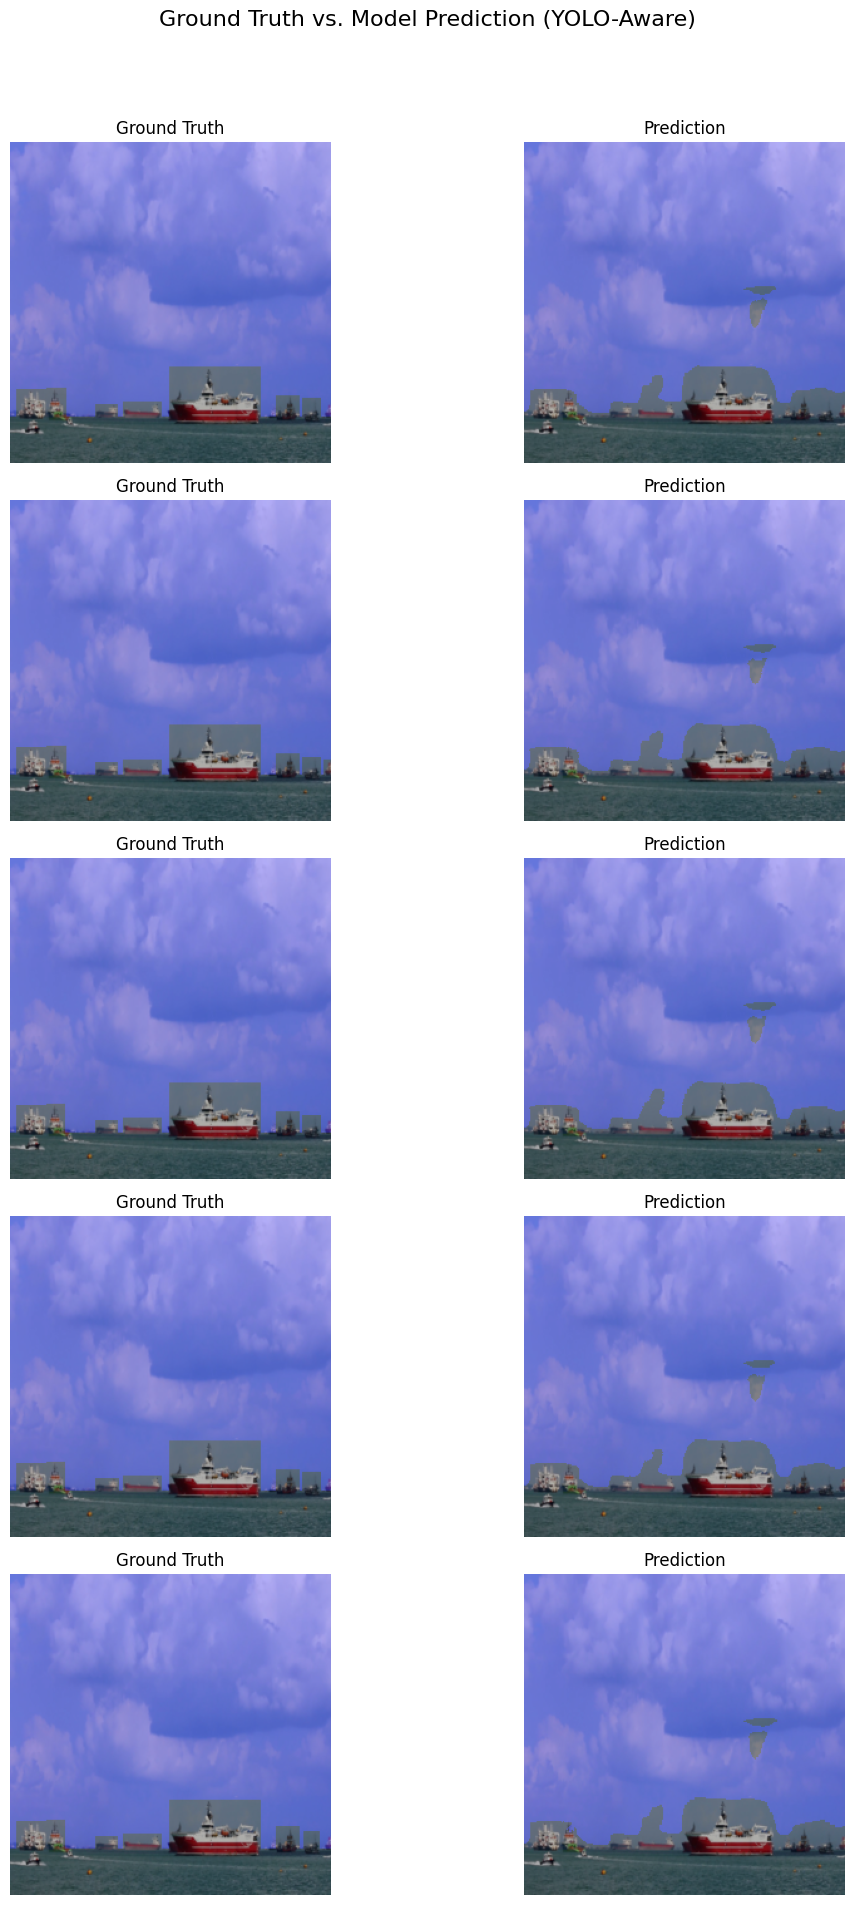

In [ ]:
# ==============================================================================
# Step 1: Setup and Environment - Ship-Aware U-Net Training with YOLO
# ==============================================================================
# Install necessary libraries including ultralytics for YOLOv8
!pip install opencv-python-headless scipy ultralytics

"""
Ship-Aware U-Net Training for Maritime Horizon Detection with YOLO-based Ship Detection

This improved training script uses YOLOv8 for accurate ship detection:
- YOLOv8 detects ships and maritime objects with high accuracy
- Creates precise ship-aware ground truth masks
- Ships are correctly labeled as "non-sky" even when above horizon
- Reduces false positives in sky classification

Improvements over color-based detection:
- Much better ship detection accuracy
- Handles various ship types and sizes
- Works in different lighting conditions
- Detects partially visible ships
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
import torchvision.models as models
from torchvision.models.resnet import ResNet18_Weights

from ultralytics import YOLO
import numpy as np
import cv2
import os
from PIL import Image
import matplotlib.pyplot as plt
import math
from google.colab import drive
from scipy.io import loadmat
import collections
import random

# Check if a GPU is available and set the device accordingly.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

# ==============================================================================
# Step 2: Connect to Google Drive and Set Up Paths
# ==============================================================================
# This will mount your Google Drive to the Colab environment.
drive.mount('/content/drive')

# --- IMPORTANT: SET YOUR PATHS HERE ---
BASE_DRIVE_PATH = '/content/drive/My Drive/SMD_Dataset'

SMD_VIDEOS_PATH = os.path.join(BASE_DRIVE_PATH, 'VIS_Onshore/Videos')
SMD_GT_PATH = os.path.join(BASE_DRIVE_PATH, 'VIS_Onshore/HorizonGT')
GDRIVE_MODEL_SAVE_PATH = os.path.join(BASE_DRIVE_PATH, 'models')
GDRIVE_PROCESSED_IMAGES_PATH = os.path.join(BASE_DRIVE_PATH, 'processed_unet_yolo_aware/images')
GDRIVE_PROCESSED_MASKS_PATH = os.path.join(BASE_DRIVE_PATH, 'processed_unet_yolo_aware/masks')

GDRIVE_PROCESSED_DATA_PATH = os.path.join(BASE_DRIVE_PATH, 'processed_unet_yolo_aware')
os.makedirs(GDRIVE_MODEL_SAVE_PATH, exist_ok=True)

# Local paths for fast access during training
LOCAL_DATA_PATH = '/content/processed_unet_yolo_aware'
LOCAL_IMAGES_PATH = os.path.join(LOCAL_DATA_PATH, 'images')
LOCAL_MASKS_PATH = os.path.join(LOCAL_DATA_PATH, 'masks')

os.makedirs(GDRIVE_PROCESSED_IMAGES_PATH, exist_ok=True)
os.makedirs(GDRIVE_PROCESSED_MASKS_PATH, exist_ok=True)

print(f"Google Drive processed data path: {GDRIVE_PROCESSED_DATA_PATH}")
print(f"Google Drive model save path: {GDRIVE_MODEL_SAVE_PATH}")
print(f"Local runtime data path: {LOCAL_DATA_PATH}")

# ==============================================================================
# Step 3: Initialize YOLO Model for Ship Detection
# ==============================================================================
print("Loading YOLOv8 model for ship detection...")

# Initialize YOLOv8 model
# We'll use YOLOv8n (nano) for speed, but you can use larger models for better accuracy
# Options: yolov8n.pt, yolov8s.pt, yolov8m.pt, yolov8l.pt, yolov8x.pt
yolo_model = YOLO('yolov8m.pt')  # Medium model for good balance of speed and accuracy

# COCO classes that are relevant for maritime scenes
# boat=8, ship is not in COCO but boat covers most maritime vessels
SHIP_CLASSES = [8]  # boat class in COCO

print("YOLOv8 model loaded successfully!")

# ==============================================================================
# Step 4: YOLO-based Ship Detection Function
# ==============================================================================
def detect_ships_with_yolo(frame, horizon_y, yolo_model, confidence_threshold=0.3):
    """
    Detect ships using YOLOv8 model.
    Returns a mask where ships are marked.

    Args:
        frame: BGR image (OpenCV format)
        horizon_y: Y-coordinate of horizon line
        yolo_model: Loaded YOLO model
        confidence_threshold: Minimum confidence for detections

    Returns:
        ship_mask: Binary mask where ships are marked as 255
    """
    h, w = frame.shape[:2]
    ship_mask = np.zeros((h, w), dtype=np.uint8)

    # Run YOLO detection
    results = yolo_model(frame, conf=confidence_threshold, classes=SHIP_CLASSES, verbose=False)

    # Process detections
    for r in results:
        boxes = r.boxes
        if boxes is not None:
            for box in boxes:
                # Get bounding box coordinates
                x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)

                # Check if the ship is near the horizon line
                # We consider ships that are above water line (below horizon)
                # and ships that cross the horizon line
                ship_bottom = y2
                ship_top = y1

                # Include ships that are:
                # 1. Completely below horizon (normal case)
                # 2. Crossing the horizon line (ship on horizon)
                # 3. Slightly above horizon (distant ships appearing above horizon)
                if ship_bottom > horizon_y - 50 or (ship_top < horizon_y + 50 and ship_bottom > horizon_y - 100):
                    # Fill the bounding box in the mask
                    # Add some padding to ensure complete ship coverage
                    pad = 5
                    x1_pad = max(0, x1 - pad)
                    y1_pad = max(0, y1 - pad)
                    x2_pad = min(w, x2 + pad)
                    y2_pad = min(h, y2 + pad)

                    ship_mask[y1_pad:y2_pad, x1_pad:x2_pad] = 255

                    # Optional: Use segmentation mask if available
                    if hasattr(box, 'masks') and box.masks is not None:
                        # YOLOv8-seg provides pixel-level masks
                        seg_mask = box.masks.data[0].cpu().numpy()
                        seg_mask = cv2.resize(seg_mask, (w, h))
                        ship_mask[seg_mask > 0.5] = 255

    # Apply morphological operations to clean up the mask
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    ship_mask = cv2.morphologyEx(ship_mask, cv2.MORPH_CLOSE, kernel)

    return ship_mask

def create_yolo_aware_mask(frame, horizon_y, yolo_model):
    """
    Create a YOLO-aware ground truth mask that properly handles ships.

    Returns:
    - Class 0: Non-sky (water + ships + objects)
    - Class 1: Sky (pure sky region only)
    """
    h, w, _ = frame.shape

    # Create initial sky mask based on horizon line
    mask = np.zeros((h, w), dtype=np.uint8)

    # Everything above horizon is initially sky
    mask[:horizon_y, :] = 1

    # Detect ships using YOLO
    ship_mask = detect_ships_with_yolo(frame, horizon_y, yolo_model)

    # Remove ships from sky region (set ships to non-sky class)
    mask[ship_mask == 255] = 0

    return mask

# ==============================================================================
# Step 5: YOLO-Aware Preprocess Data for U-Net
# ==============================================================================
def preprocess_smd_with_yolo():
    """
    Extracts frames and creates YOLO-aware ground truth segmentation masks.
    Saves the output to your Google Drive.
    """
    print("Starting YOLO-Aware SMD preprocessing for Segmentation...")
    video_files = sorted([f for f in os.listdir(SMD_VIDEOS_PATH) if f.endswith('.avi')])

    processed_count = 0
    total_videos = len(video_files)
    ships_detected_count = 0

    for i, video_file in enumerate(video_files):
        print(f"Processing video {i+1}/{total_videos}: {video_file}")
        video_name_without_ext = os.path.splitext(video_file)[0]
        gt_filename = f"{video_name_without_ext}_HorizonGT.mat"
        video_path = os.path.join(SMD_VIDEOS_PATH, video_file)
        gt_path = os.path.join(SMD_GT_PATH, gt_filename)

        if not os.path.exists(gt_path):
            continue

        gt_data = loadmat(gt_path)
        horizon_key = None
        for key in gt_data.keys():
            if not key.startswith('__'):
                horizon_key = key
                break

        if horizon_key is None:
            continue

        struct_array = gt_data[horizon_key]
        if struct_array.size == 0:
            continue

        cap = cv2.VideoCapture(video_path)
        frame_idx = 0

        while True:
            ret, frame = cap.read()
            if not ret:
                break
            if frame_idx >= struct_array.shape[1]:
                break

            try:
                # Extract horizon line parameters
                frame_struct = struct_array[0, frame_idx]
                x_point = float(frame_struct['X'][0,0])
                y_point = float(frame_struct['Y'][0,0])
                nx = float(frame_struct['Nx'][0,0])
                ny = float(frame_struct['Ny'][0,0])

                h, w, _ = frame.shape

                # Calculate horizon y-coordinate
                if abs(ny) < 1e-6:
                    horizon_y = int(y_point)
                else:
                    c = -(nx * x_point + ny * y_point)
                    horizon_y = int(-c / ny)

                # Clamp horizon to frame bounds
                horizon_y = max(0, min(h-1, horizon_y))

                # Create YOLO-aware mask
                mask = create_yolo_aware_mask(frame, horizon_y, yolo_model)

                # Skip frames with invalid masks
                if mask.min() == mask.max():
                    frame_idx += 1
                    continue

                # Count ships detected
                ship_mask = detect_ships_with_yolo(frame, horizon_y, yolo_model)
                if np.any(ship_mask == 255):
                    ships_detected_count += 1

            except (IndexError, TypeError, KeyError, ValueError) as e:
                frame_idx += 1
                continue

            # Save frame and mask
            frame_filename = f"{video_name_without_ext}_frame_{frame_idx:04d}.jpg"
            mask_filename = f"{video_name_without_ext}_frame_{frame_idx:04d}.png"

            cv2.imwrite(os.path.join(GDRIVE_PROCESSED_IMAGES_PATH, frame_filename), frame)
            cv2.imwrite(os.path.join(GDRIVE_PROCESSED_MASKS_PATH, mask_filename), mask)

            # Optional: Save debug visualization every 100 frames
            if processed_count % 100 == 0:
                vis_frame = frame.copy()
                overlay = np.zeros_like(frame)
                overlay[mask == 1] = [0, 0, 255]  # Sky in blue
                overlay[ship_mask == 255] = [0, 255, 0]  # Ships in green
                vis_frame = cv2.addWeighted(vis_frame, 0.7, overlay, 0.3, 0)
                cv2.line(vis_frame, (0, horizon_y), (w, horizon_y), (255, 255, 0), 2)

                # Draw YOLO bounding boxes
                results = yolo_model(frame, conf=0.3, classes=SHIP_CLASSES, verbose=False)
                for r in results:
                    boxes = r.boxes
                    if boxes is not None:
                        for box in boxes:
                            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
                            cv2.rectangle(vis_frame, (x1, y1), (x2, y2), (0, 255, 255), 2)
                            conf = box.conf[0].cpu().numpy()
                            cv2.putText(vis_frame, f"Ship {conf:.2f}", (x1, y1-10),
                                      cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 2)

                debug_filename = f"debug_{video_name_without_ext}_frame_{frame_idx:04d}.jpg"
                cv2.imwrite(os.path.join(GDRIVE_PROCESSED_IMAGES_PATH, debug_filename), vis_frame)

            frame_idx += 1
            processed_count += 1

            # Process every 10th frame to speed up (optional)
            # frame_idx += 10

        cap.release()

    print(f"YOLO-Aware preprocessing complete. Total frames processed: {processed_count}")
    print(f"Frames with ships detected: {ships_detected_count} ({ships_detected_count/processed_count*100:.1f}%)")

# Check if the processed folder on Drive is empty. If so, run preprocessing.
if not os.listdir(GDRIVE_PROCESSED_IMAGES_PATH):
    print("Processed data not found on Google Drive. Running YOLO preprocessing. This may take a while.")
    preprocess_smd_with_yolo()
else:
    print("Processed data found on Google Drive.")

# Copy the entire folder from Drive to the local runtime
if not os.path.exists(LOCAL_DATA_PATH):
    print(f"Copying data from '{GDRIVE_PROCESSED_DATA_PATH}' to local runtime '{LOCAL_DATA_PATH}'...")
    !cp -r "{GDRIVE_PROCESSED_DATA_PATH}" "{LOCAL_DATA_PATH}"
    print("Data successfully copied to local runtime.")
else:
    print("Data already exists in local runtime. Skipping copy.")

# ==============================================================================
# The rest of the code remains the same (Dataset, Model, Training)
# ==============================================================================
IMG_SIZE = (256, 256)
BATCH_SIZE = 16

class SegmentationDataset(Dataset):
    def __init__(self, image_files, masks_dir, size, is_train=False):
        self.image_files = image_files
        self.masks_dir = masks_dir
        self.size = size
        self.is_train = is_train

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = self.image_files[idx]
        img_name = os.path.basename(img_path)
        mask_name = img_name.replace('.jpg', '.png')
        mask_path = os.path.join(self.masks_dir, mask_name)

        if not os.path.exists(mask_path):
            raise FileNotFoundError(f"Mask file not found: {mask_path}")

        try:
            image = Image.open(img_path).convert("RGB")
            mask = Image.open(mask_path).convert("L")
        except Exception as e:
            raise IOError(f"Error loading image {img_path} or mask {mask_path}: {e}")

        # Resize first
        image = TF.resize(image, self.size)
        mask = TF.resize(mask, self.size, interpolation=TF.InterpolationMode.NEAREST)

        if self.is_train:
            # Random horizontal flip
            if random.random() > 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)

            # Random affine transformation
            angle = random.uniform(-15, 15)
            translate = (random.uniform(0, 0.1 * self.size[0]), random.uniform(0, 0.1 * self.size[1]))
            scale = random.uniform(0.9, 1.1)
            shear = random.uniform(-10, 10)
            image = TF.affine(image, angle, translate, scale, shear, fill=0)
            mask = TF.affine(mask, angle, translate, scale, shear, fill=0)

            # Color jitter (only on the image)
            if random.random() > 0.5:
                image = TF.adjust_brightness(image, brightness_factor=random.uniform(0.7, 1.3))
                image = TF.adjust_contrast(image, contrast_factor=random.uniform(0.7, 1.3))
                image = TF.adjust_saturation(image, saturation_factor=random.uniform(0.7, 1.3))
                image = TF.adjust_hue(image, hue_factor=random.uniform(-0.1, 0.1))

        # Convert to tensor and normalize
        image = TF.to_tensor(image)
        mask_np = np.array(mask)
        mask_tensor = torch.from_numpy(mask_np).long()

        image = TF.normalize(image, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

        return image, mask_tensor

# Implement Video-Based Splitting
all_image_files = sorted([os.path.join(LOCAL_IMAGES_PATH, f) for f in os.listdir(LOCAL_IMAGES_PATH)
                         if f.endswith('.jpg') and not f.startswith('debug_')])

# Validate dataset
def validate_dataset(image_files, masks_dir):
    valid_files = []
    missing_masks = []

    for img_path in image_files:
        img_name = os.path.basename(img_path)
        mask_name = img_name.replace('.jpg', '.png')
        mask_path = os.path.join(masks_dir, mask_name)

        if os.path.exists(mask_path):
            valid_files.append(img_path)
        else:
            missing_masks.append(mask_name)

    if missing_masks:
        print(f"Warning: {len(missing_masks)} image files don't have corresponding masks:")
        for mask in missing_masks[:5]:
            print(f"  - {mask}")
        if len(missing_masks) > 5:
            print(f"  ... and {len(missing_masks) - 5} more")
        print(f"Using {len(valid_files)} valid image-mask pairs out of {len(image_files)} total images.")

    return valid_files

all_image_files = validate_dataset(all_image_files, LOCAL_MASKS_PATH)

if all_image_files:
    video_groups = collections.defaultdict(list)
    for f in all_image_files:
        prefix = '_'.join(os.path.basename(f).split('_')[:-2])
        video_groups[prefix].append(f)

    unique_videos = list(video_groups.keys())
    random.seed(42)
    random.shuffle(unique_videos)

    split_idx_1 = int(0.8 * len(unique_videos))
    split_idx_2 = int(0.9 * len(unique_videos))
    train_videos = unique_videos[:split_idx_1]
    val_videos = unique_videos[split_idx_1:split_idx_2]
    test_videos = unique_videos[split_idx_2:]

    train_files = [f for video in train_videos for f in video_groups[video]]
    val_files = [f for video in val_videos for f in video_groups[video]]
    test_files = [f for video in test_videos for f in video_groups[video]]

    train_dataset = SegmentationDataset(train_files, LOCAL_MASKS_PATH, IMG_SIZE, is_train=True)
    val_dataset = SegmentationDataset(val_files, LOCAL_MASKS_PATH, IMG_SIZE, is_train=False)
    test_dataset = SegmentationDataset(test_files, LOCAL_MASKS_PATH, IMG_SIZE, is_train=False)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

    print(f"\nDataset loaded from local runtime and split by video.")
    print(f"Total videos: {len(unique_videos)} -> Train: {len(train_videos)}, Val: {len(val_videos)}, Test: {len(test_videos)}")
    print(f"Total frames: {len(all_image_files)} -> Train: {len(train_files)}, Val: {len(val_files)}, Test: {len(test_files)}")
else:
    print("\n--- ERROR: Dataset is empty ---")

# U-Net Model Definition
class UNet(nn.Module):
    def __init__(self, n_classes=2, dropout_rate=0.3):
        super().__init__()
        self.n_classes = n_classes

        resnet = models.resnet18(weights=ResNet18_Weights.DEFAULT)
        self.base_layers = list(resnet.children())
        self.layer0 = nn.Sequential(*self.base_layers[:3])
        self.layer1 = nn.Sequential(*self.base_layers[3:5])
        self.layer2 = self.base_layers[5]
        self.layer3 = self.base_layers[6]
        self.layer4 = self.base_layers[7]

        self.upconv4 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec4 = self.conv_block(256 + 256, 256, dropout_rate)
        self.upconv3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec3 = self.conv_block(128 + 128, 128, dropout_rate)
        self.upconv2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = self.conv_block(64 + 64, 64, dropout_rate)
        self.upconv1 = nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2)
        self.dec1 = self.conv_block(64 + 64, 32)
        self.final_upconv = nn.ConvTranspose2d(32, 32, kernel_size=2, stride=2)
        self.final_conv = nn.Conv2d(32, n_classes, kernel_size=1)

    def conv_block(self, in_channels, out_channels, dropout_rate=0.0):
        layers = [
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        ]
        if dropout_rate > 0:
            layers.append(nn.Dropout(dropout_rate))
        return nn.Sequential(*layers)

    def forward(self, x):
        # Encoder
        x0_pool = self.layer0(x)
        x1 = self.layer1(x0_pool)
        x2 = self.layer2(x1)
        x3 = self.layer3(x2)
        x4 = self.layer4(x3)

        # Decoder
        d4 = self.upconv4(x4)
        d4 = torch.cat([d4, x3], dim=1)
        d4 = self.dec4(d4)

        d3 = self.upconv3(d4)
        d3 = torch.cat([d3, x2], dim=1)
        d3 = self.dec3(d3)

        d2 = self.upconv2(d3)
        d2 = torch.cat([d2, x1], dim=1)
        d2 = self.dec2(d2)

        d1 = self.upconv1(d2)
        d1 = torch.cat([d1, x0_pool], dim=1)
        d1 = self.dec1(d1)

        d0 = self.final_upconv(d1)
        return self.final_conv(d0)

# Define Dice Loss and IoU Metric
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)
        probs_sky = probs[:, 1, :, :]
        targets_sky = (targets == 1).float()

        intersection = (probs_sky * targets_sky).sum()
        dice_coeff = (2. * intersection + self.smooth) / (probs_sky.sum() + targets_sky.sum() + self.smooth)

        return 1 - dice_coeff

def iou_score(outputs, masks):
    masks = masks.to(outputs.device)
    preds = torch.argmax(outputs, dim=1)
    intersection = ((preds == 1) & (masks == 1)).float().sum()
    union = ((preds == 1) | (masks == 1)).float().sum()
    iou = (intersection + 1e-6) / (union + 1e-6)
    return iou.item()

model = UNet(n_classes=2, dropout_rate=0.3).to(device)

LEARNING_RATE = 1e-4
NUM_EPOCHS = 50
WEIGHT_DECAY = 1e-5

criterion_ce = nn.CrossEntropyLoss()
criterion_dice = DiceLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = ReduceLROnPlateau(optimizer, 'min', factor=0.1, patience=5, verbose=True)

def train_model(model, train_loader, val_loader, optimizer, scheduler, num_epochs):
    print("\n--- Starting YOLO-Aware U-Net Training ---")
    best_iou = 0.0
    patience = 10
    epochs_no_improve = 0
    best_val_loss = float('inf')
    model_save_path = os.path.join(GDRIVE_MODEL_SAVE_PATH, 'best_unet_yolo_aware_smd.pth')

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device, dtype=torch.long)
            optimizer.zero_grad()
            outputs = model(images)

            # Combined Loss
            loss_ce = criterion_ce(outputs, masks)
            loss_dice = criterion_dice(outputs, masks)
            loss = 0.5 * loss_ce + 0.5 * loss_dice

            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        val_iou = 0.0
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device, dtype=torch.long)
                outputs = model(images)
                loss_ce = criterion_ce(outputs, masks)
                loss_dice = criterion_dice(outputs, masks)
                loss = 0.5 * loss_ce + 0.5 * loss_dice
                val_loss += loss.item() * images.size(0)
                for i in range(images.size(0)):
                    val_iou += iou_score(outputs[i].unsqueeze(0), masks[i].unsqueeze(0))

        val_loss /= len(val_loader.dataset)
        val_iou /= len(val_loader.dataset)
        print(f"Epoch {epoch+1}/{num_epochs} -> Train Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}, Val IoU: {val_iou:.4f}")

        scheduler.step(val_loss)

        if val_iou > best_iou:
            best_iou = val_iou
            torch.save(model.state_dict(), model_save_path)
            print(f"  -> Model saved with new best validation IoU: {best_iou:.4f}")
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"--- Early stopping triggered after {patience} epochs with no improvement. ---")
            break

    print(f"--- Finished Training. Best validation IoU: {best_iou:.4f} ---")
    print(f"Best model saved to: {model_save_path}")

# Visualization Function
def visualize_segmentation(model, loader, num_images=5):
    model.eval()
    try:
        images, masks = next(iter(loader))
    except StopIteration:
        print("Cannot visualize. The data loader is empty.")
        return
    images, masks = images.to(device), masks.to(device)

    with torch.no_grad():
        outputs = model(images)

    preds = torch.argmax(outputs, dim=1).cpu().numpy()
    images = images.cpu()

    sky_color = np.array([0, 0, 255])

    fig, axes = plt.subplots(num_images, 2, figsize=(12, num_images * 4))
    if num_images == 1: axes = np.array([axes])
    fig.suptitle("Ground Truth vs. Model Prediction (YOLO-Aware)", fontsize=16)

    for i in range(min(num_images, len(images))):
        img_tensor = images[i]
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        img_display = (img_tensor * std + mean).permute(1, 2, 0).numpy()
        img_display = np.clip(img_display, 0, 1)

        gt_mask = masks[i].cpu().numpy()
        gt_overlay = np.zeros_like(img_display)
        gt_overlay[gt_mask == 1] = sky_color / 255.0
        gt_viz = cv2.addWeighted(img_display, 0.7, gt_overlay, 0.3, 0)
        axes[i, 0].imshow(gt_viz)
        axes[i, 0].set_title("Ground Truth")
        axes[i, 0].axis('off')

        pred_mask = preds[i]
        pred_overlay = np.zeros_like(img_display)
        pred_overlay[pred_mask == 1] = sky_color / 255.0
        pred_viz = cv2.addWeighted(img_display, 0.7, pred_overlay, 0.3, 0)
        axes[i, 1].imshow(pred_viz)
        axes[i, 1].set_title("Prediction")
        axes[i, 1].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Main Execution Block
if 'train_loader' in locals() and 'val_loader' in locals():
    # Train the model
    train_model(model, train_loader, val_loader, optimizer, scheduler, NUM_EPOCHS)

    # Load the best model and visualize results
    best_model_path = os.path.join(GDRIVE_MODEL_SAVE_PATH, 'best_unet_yolo_aware_smd.pth')
    if os.path.exists(best_model_path):
        print("\n--- Visualizing results with the best YOLO-aware model ---")
        model.load_state_dict(torch.load(best_model_path))
        visualize_segmentation(model, val_loader)
    else:
        print("\n--- No saved YOLO-aware model found to visualize. ---")
else:
    print("\n--- ERROR: Training skipped because dataset was not loaded ---")


# U-Net Training for HLD and Segmentation Using a RT-DETR Obj. Det. Model for Ship-aware Preprocessing

Using device: cuda
GPU Name: Tesla T4
Mounted at /content/drive
Google Drive processed data path: /content/drive/My Drive/SMD_Dataset/processed_unet_rtdetr_aware
Google Drive model save path: /content/drive/My Drive/SMD_Dataset/models
Local runtime data path: /content/processed_unet_rtdetr_aware
Loading HF RT-DETR model for ship detection...


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


HF RT-DETR model loaded successfully!
Processed data not found on Google Drive. Running RT-DETR preprocessing. This may take a while.
Starting RT-DETR-Aware SMD preprocessing for Segmentation...
Processing video 1/40: MVI_1448_VIS_Haze.avi
Processing video 2/40: MVI_1451_VIS_Haze.avi
Processing video 3/40: MVI_1452_VIS_Haze.avi
Processing video 4/40: MVI_1469_VIS.avi
Processing video 5/40: MVI_1470_VIS.avi
Processing video 6/40: MVI_1471_VIS.avi
Processing video 7/40: MVI_1474_VIS.avi
Processing video 8/40: MVI_1478_VIS.avi
Processing video 9/40: MVI_1479_VIS.avi
Processing video 10/40: MVI_1481_VIS.avi
Processing video 11/40: MVI_1482_VIS.avi
Processing video 12/40: MVI_1483_VIS.avi
Processing video 13/40: MVI_1484_VIS.avi
Processing video 14/40: MVI_1485_VIS.avi
Processing video 15/40: MVI_1486_VIS.avi
Processing video 16/40: MVI_1578_VIS.avi
Processing video 17/40: MVI_1582_VIS.avi
Processing video 18/40: MVI_1583_VIS.avi
Processing video 19/40: MVI_1584_VIS.avi
Processing video 20/

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 164MB/s]



--- Starting RT-DETR-Aware U-Net Training ---
Epoch 1/50 -> Train Loss: 0.1250, Val Loss: 0.0347, Val IoU: 0.9708
  -> Model saved with new best validation IoU: 0.9708
Epoch 2/50 -> Train Loss: 0.0162, Val Loss: 0.0320, Val IoU: 0.9734
  -> Model saved with new best validation IoU: 0.9734
Epoch 3/50 -> Train Loss: 0.0107, Val Loss: 0.0352, Val IoU: 0.9722
Epoch 4/50 -> Train Loss: 0.0089, Val Loss: 0.0306, Val IoU: 0.9752
  -> Model saved with new best validation IoU: 0.9752
Epoch 5/50 -> Train Loss: 0.0081, Val Loss: 0.0301, Val IoU: 0.9756
  -> Model saved with new best validation IoU: 0.9756
Epoch 6/50 -> Train Loss: 0.0077, Val Loss: 0.0345, Val IoU: 0.9744
Epoch 7/50 -> Train Loss: 0.0072, Val Loss: 0.0363, Val IoU: 0.9719
Epoch 8/50 -> Train Loss: 0.0070, Val Loss: 0.0438, Val IoU: 0.9680
Epoch 9/50 -> Train Loss: 0.0067, Val Loss: 0.0390, Val IoU: 0.9717
Epoch 10/50 -> Train Loss: 0.0065, Val Loss: 0.0332, Val IoU: 0.9750
Epoch 11/50 -> Train Loss: 0.0065, Val Loss: 0.0344, Val

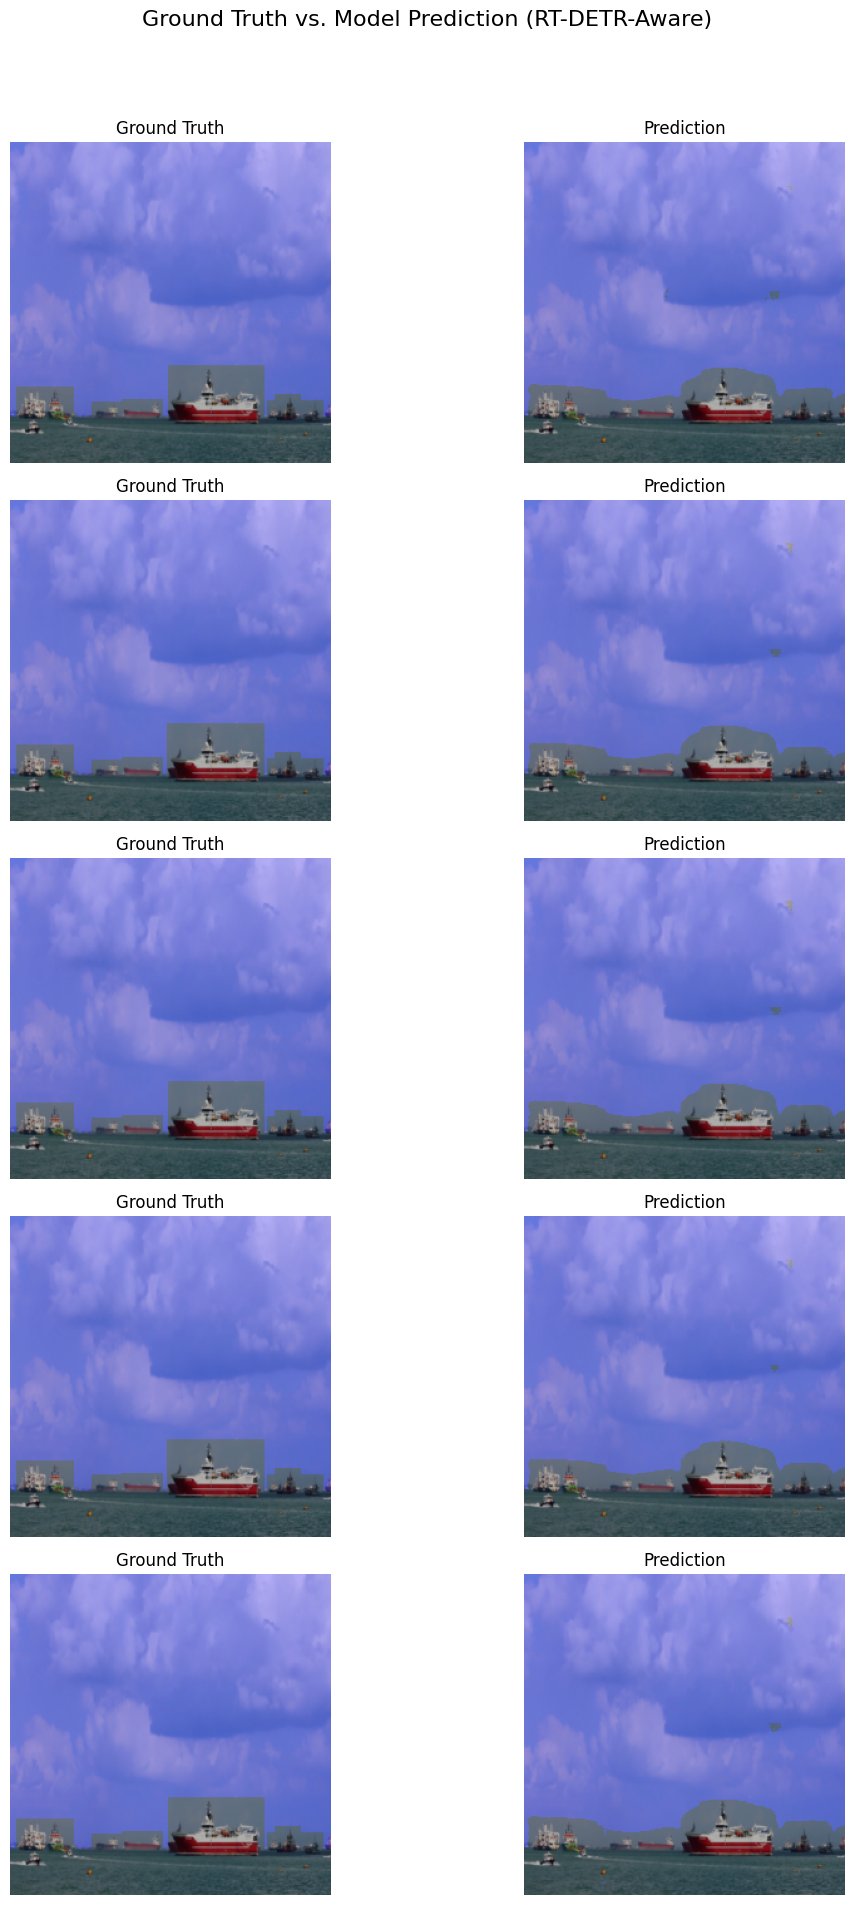

In [ ]:
# ==============================================================================
# Step 1: Setup and Environment - Ship-Aware U-Net Training with HF RT-DETR
# ==============================================================================
# Install necessary libraries (Hugging Face Transformers RT-DETR)
!pip install -q opencv-python-headless scipy transformers timm accelerate safetensors

"""
Ship-Aware U-Net Training for Maritime Horizon Detection with RT-DETR-based Ship Detection

This improved training script uses a Hugging Face RT-DETR checkpoint for accurate ship detection:
- RT-DETR detects ships and maritime objects with high accuracy when fine-tuned on maritime data
- Creates precise ship-aware ground truth masks
- Ships are correctly labeled as "non-sky" even when above horizon
- Reduces false positives in sky classification

Improvements over color-based detection:
- Much better ship detection accuracy
- Handles various ship types and sizes
- Works in different lighting conditions
- Detects partially visible ships
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
import torchvision.models as models
from torchvision.models.resnet import ResNet18_Weights

from transformers import AutoImageProcessor, AutoModelForObjectDetection
import numpy as np
import cv2
import os
from PIL import Image
import matplotlib.pyplot as plt
import math
from google.colab import drive
from scipy.io import loadmat
import collections
import random

# Check if a GPU is available and set the device accordingly.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

# ==============================================================================
# Step 2: Connect to Google Drive and Set Up Paths
# ==============================================================================
# This will mount your Google Drive to the Colab environment.
drive.mount('/content/drive')

# --- IMPORTANT: SET YOUR PATHS HERE ---
BASE_DRIVE_PATH = '/content/drive/My Drive/SMD_Dataset'

SMD_VIDEOS_PATH = os.path.join(BASE_DRIVE_PATH, 'VIS_Onshore/Videos')
SMD_GT_PATH = os.path.join(BASE_DRIVE_PATH, 'VIS_Onshore/HorizonGT')
GDRIVE_MODEL_SAVE_PATH = os.path.join(BASE_DRIVE_PATH, 'models')
GDRIVE_PROCESSED_IMAGES_PATH = os.path.join(BASE_DRIVE_PATH, 'processed_unet_rtdetr_aware/images')
GDRIVE_PROCESSED_MASKS_PATH = os.path.join(BASE_DRIVE_PATH, 'processed_unet_rtdetr_aware/masks')

GDRIVE_PROCESSED_DATA_PATH = os.path.join(BASE_DRIVE_PATH, 'processed_unet_rtdetr_aware')
os.makedirs(GDRIVE_MODEL_SAVE_PATH, exist_ok=True)

# Local paths for fast access during training
LOCAL_DATA_PATH = '/content/processed_unet_rtdetr_aware'
LOCAL_IMAGES_PATH = os.path.join(LOCAL_DATA_PATH, 'images')
LOCAL_MASKS_PATH = os.path.join(LOCAL_DATA_PATH, 'masks')

os.makedirs(GDRIVE_PROCESSED_IMAGES_PATH, exist_ok=True)
os.makedirs(GDRIVE_PROCESSED_MASKS_PATH, exist_ok=True)

print(f"Google Drive processed data path: {GDRIVE_PROCESSED_DATA_PATH}")
print(f"Google Drive model save path: {GDRIVE_MODEL_SAVE_PATH}")
print(f"Local runtime data path: {LOCAL_DATA_PATH}")

# ==============================================================================
# Step 3: Initialize RT-DETR Model for Ship Detection
# ==============================================================================
print("Loading HF RT-DETR model for ship detection...")

# Path to your RT-DETR checkpoint folder on Drive (must contain config.json and model.safetensors)
# EXAMPLE: '/content/drive/My Drive/SMD_Dataset/models/rtdetr/final_best_model'
GDRIVE_RTDETR_MODEL_DIR = '/content/drive/My Drive/SMD_Dataset/models/rtdetr/final_best_model'

# Ship-relevant class ids (adapt to your checkpoint). Example from provided config:
# 0 Boat, 1 Buoy, 2 Ferry, 3 Flying bird-plane, 4 Kayak, 5 Other, 6 Sail boat, 7 Speed boat, 8 Vessel-ship
SHIP_CLASSES = [0, 1, 2, 4, 6, 7, 8]

try:
    rtdetr_processor = AutoImageProcessor.from_pretrained(GDRIVE_RTDETR_MODEL_DIR)
    rtdetr_model = AutoModelForObjectDetection.from_pretrained(GDRIVE_RTDETR_MODEL_DIR)
    rtdetr_model.eval()
    rtdetr_model.to(device)
    print("HF RT-DETR model loaded successfully!")
except Exception as e:
    print(f"[ERROR] Failed to load HF RT-DETR from '{GDRIVE_RTDETR_MODEL_DIR}': {e}")
    rtdetr_processor = None
    rtdetr_model = None

# ==============================================================================
# Step 4: RT-DETR-based Ship Detection Function
# ==============================================================================
def detect_ships_with_rtdetr(frame, horizon_y, hf_processor, hf_model, confidence_threshold=0.3, ship_classes=SHIP_CLASSES):
    """
    Detect ships using a Hugging Face RT-DETR checkpoint. Returns a mask where ships are marked.
    """
    h, w = frame.shape[:2]
    ship_mask = np.zeros((h, w), dtype=np.uint8)

    if hf_processor is None or hf_model is None:
        return ship_mask

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    inputs = hf_processor(images=frame_rgb, return_tensors="pt")
    with torch.no_grad():
        outputs = hf_model(**{k: v.to(hf_model.device) for k, v in inputs.items()})
    target_sizes = torch.tensor([(h, w)], device=hf_model.device)
    results = hf_processor.post_process_object_detection(outputs, target_sizes=target_sizes, threshold=confidence_threshold)[0]

    boxes = results.get("boxes")
    labels = results.get("labels")
    if boxes is None:
        return ship_mask

    boxes = boxes.detach().cpu().numpy()
    labels = labels.detach().cpu().numpy().astype(int)

    for i, (x1, y1, x2, y2) in enumerate(boxes):
        class_id = int(labels[i])
        if ship_classes and class_id not in ship_classes:
            continue
        ship_bottom = int(y2)
        ship_top = int(y1)
        if ship_bottom > horizon_y - 50 or (ship_top < horizon_y + 50 and ship_bottom > horizon_y - 100):
            pad = 5
            x1_pad = max(0, int(x1) - pad)
            y1_pad = max(0, int(y1) - pad)
            x2_pad = min(w, int(x2) + pad)
            y2_pad = min(h, int(y2) + pad)
            ship_mask[y1_pad:y2_pad, x1_pad:x2_pad] = 255

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    ship_mask = cv2.morphologyEx(ship_mask, cv2.MORPH_CLOSE, kernel)
    return ship_mask

def create_rtdetr_aware_mask(frame, horizon_y, hf_processor, hf_model):
    """
    Create a RTDETR-aware ground truth mask that properly handles ships.

    Returns:
    - Class 0: Non-sky (water + ships + objects)
    - Class 1: Sky (pure sky region only)
    """
    h, w, _ = frame.shape

    # Create initial sky mask based on horizon line
    mask = np.zeros((h, w), dtype=np.uint8)

    # Everything above horizon is initially sky
    mask[:horizon_y, :] = 1

    # Detect ships using RT-DETR
    ship_mask = detect_ships_with_rtdetr(frame, horizon_y, hf_processor, hf_model)

    # Remove ships from sky region (set ships to non-sky class)
    mask[ship_mask == 255] = 0

    return mask

# ==============================================================================
# Step 5: RT-DETR-Aware Preprocess Data for U-Net
# ==============================================================================
def preprocess_smd_with_rtdetr():
    """
    Extracts frames and creates RTDETR-aware ground truth segmentation masks.
    Saves the output to your Google Drive.
    """
    print("Starting RT-DETR-Aware SMD preprocessing for Segmentation...")
    video_files = sorted([f for f in os.listdir(SMD_VIDEOS_PATH) if f.endswith('.avi')])

    processed_count = 0
    total_videos = len(video_files)
    ships_detected_count = 0

    for i, video_file in enumerate(video_files):
        print(f"Processing video {i+1}/{total_videos}: {video_file}")
        video_name_without_ext = os.path.splitext(video_file)[0]
        gt_filename = f"{video_name_without_ext}_HorizonGT.mat"
        video_path = os.path.join(SMD_VIDEOS_PATH, video_file)
        gt_path = os.path.join(SMD_GT_PATH, gt_filename)

        if not os.path.exists(gt_path):
            continue

        gt_data = loadmat(gt_path)
        horizon_key = None
        for key in gt_data.keys():
            if not key.startswith('__'):
                horizon_key = key
                break

        if horizon_key is None:
            continue

        struct_array = gt_data[horizon_key]
        if struct_array.size == 0:
            continue

        cap = cv2.VideoCapture(video_path)
        frame_idx = 0

        while True:
            ret, frame = cap.read()
            if not ret:
                break
            if frame_idx >= struct_array.shape[1]:
                break

            try:
                # Extract horizon line parameters
                frame_struct = struct_array[0, frame_idx]
                x_point = float(frame_struct['X'][0,0])
                y_point = float(frame_struct['Y'][0,0])
                nx = float(frame_struct['Nx'][0,0])
                ny = float(frame_struct['Ny'][0,0])

                h, w, _ = frame.shape

                # Calculate horizon y-coordinate
                if abs(ny) < 1e-6:
                    horizon_y = int(y_point)
                else:
                    c = -(nx * x_point + ny * y_point)
                    horizon_y = int(-c / ny)

                # Clamp horizon to frame bounds
                horizon_y = max(0, min(h-1, horizon_y))

                # Create RT-DETR-aware mask
                mask = create_rtdetr_aware_mask(frame, horizon_y, rtdetr_processor, rtdetr_model)

                # Skip frames with invalid masks
                if mask.min() == mask.max():
                    frame_idx += 1
                    continue

                # Count ships detected
                ship_mask = detect_ships_with_rtdetr(frame, horizon_y, rtdetr_processor, rtdetr_model)
                if np.any(ship_mask == 255):
                    ships_detected_count += 1

            except (IndexError, TypeError, KeyError, ValueError) as e:
                frame_idx += 1
                continue

            # Save frame and mask
            frame_filename = f"{video_name_without_ext}_frame_{frame_idx:04d}.jpg"
            mask_filename = f"{video_name_without_ext}_frame_{frame_idx:04d}.png"

            cv2.imwrite(os.path.join(GDRIVE_PROCESSED_IMAGES_PATH, frame_filename), frame)
            cv2.imwrite(os.path.join(GDRIVE_PROCESSED_MASKS_PATH, mask_filename), mask)

            # Optional: Save debug visualization every 100 frames
            if processed_count % 100 == 0:
                vis_frame = frame.copy()
                overlay = np.zeros_like(frame)
                overlay[mask == 1] = [0, 0, 255]  # Sky in blue
                overlay[ship_mask == 255] = [0, 255, 0]  # Ships in green
                vis_frame = cv2.addWeighted(vis_frame, 0.7, overlay, 0.3, 0)
                cv2.line(vis_frame, (0, horizon_y), (w, horizon_y), (255, 255, 0), 2)

                # Draw RT-DETR bounding boxes
                try:
                    inputs = rtdetr_processor(images=cv2.cvtColor(frame, cv2.COLOR_BGR2RGB), return_tensors="pt")
                    with torch.no_grad():
                        outputs = rtdetr_model(**{k: v.to(rtdetr_model.device) for k, v in inputs.items()})
                    target_sizes = torch.tensor([(h, w)], device=rtdetr_model.device)
                    det = rtdetr_processor.post_process_object_detection(outputs, target_sizes=target_sizes, threshold=0.3)[0]
                    if det and 'boxes' in det:
                        b = det['boxes'].cpu().numpy().astype(int)
                        s = det['scores'].cpu().numpy()
                        l = det['labels'].cpu().numpy().astype(int)
                        for (x1, y1, x2, y2), conf, cls in zip(b, s, l):
                            if SHIP_CLASSES and cls not in SHIP_CLASSES:
                                continue
                            cv2.rectangle(vis_frame, (x1, y1), (x2, y2), (0, 255, 255), 2)
                            cv2.putText(vis_frame, f"Ship {conf:.2f}", (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 2)
                except Exception:
                    pass

                debug_filename = f"debug_{video_name_without_ext}_frame_{frame_idx:04d}.jpg"
                cv2.imwrite(os.path.join(GDRIVE_PROCESSED_IMAGES_PATH, debug_filename), vis_frame)

            frame_idx += 1
            processed_count += 1

            # Process every 10th frame to speed up (optional)
            # frame_idx += 10

        cap.release()

    print(f"RT-DETR-Aware preprocessing complete. Total frames processed: {processed_count}")
    print(f"Frames with ships detected: {ships_detected_count} ({ships_detected_count/processed_count*100:.1f}%)")

# Check if the processed folder on Drive is empty. If so, run preprocessing.
if not os.listdir(GDRIVE_PROCESSED_IMAGES_PATH):
    print("Processed data not found on Google Drive. Running RT-DETR preprocessing. This may take a while.")
    preprocess_smd_with_rtdetr()
else:
    print("Processed data found on Google Drive.")

# Copy the entire folder from Drive to the local runtime
if not os.path.exists(LOCAL_DATA_PATH):
    print(f"Copying data from '{GDRIVE_PROCESSED_DATA_PATH}' to local runtime '{LOCAL_DATA_PATH}'...")
    !cp -r "{GDRIVE_PROCESSED_DATA_PATH}" "{LOCAL_DATA_PATH}"
    print("Data successfully copied to local runtime.")
else:
    print("Data already exists in local runtime. Skipping copy.")

# ==============================================================================
# The rest of the code remains the same (Dataset, Model, Training)
# ==============================================================================
IMG_SIZE = (256, 256)
BATCH_SIZE = 16

class SegmentationDataset(Dataset):
    def __init__(self, image_files, masks_dir, size, is_train=False):
        self.image_files = image_files
        self.masks_dir = masks_dir
        self.size = size
        self.is_train = is_train

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = self.image_files[idx]
        img_name = os.path.basename(img_path)
        mask_name = img_name.replace('.jpg', '.png')
        mask_path = os.path.join(self.masks_dir, mask_name)

        if not os.path.exists(mask_path):
            raise FileNotFoundError(f"Mask file not found: {mask_path}")

        try:
            image = Image.open(img_path).convert("RGB")
            mask = Image.open(mask_path).convert("L")
        except Exception as e:
            raise IOError(f"Error loading image {img_path} or mask {mask_path}: {e}")

        # Resize first
        image = TF.resize(image, self.size)
        mask = TF.resize(mask, self.size, interpolation=TF.InterpolationMode.NEAREST)

        if self.is_train:
            # Random horizontal flip
            if random.random() > 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)

            # Random affine transformation
            angle = random.uniform(-15, 15)
            translate = (random.uniform(0, 0.1 * self.size[0]), random.uniform(0, 0.1 * self.size[1]))
            scale = random.uniform(0.9, 1.1)
            shear = random.uniform(-10, 10)
            image = TF.affine(image, angle, translate, scale, shear, fill=0)
            mask = TF.affine(mask, angle, translate, scale, shear, fill=0)

            # Color jitter (only on the image)
            if random.random() > 0.5:
                image = TF.adjust_brightness(image, brightness_factor=random.uniform(0.7, 1.3))
                image = TF.adjust_contrast(image, contrast_factor=random.uniform(0.7, 1.3))
                image = TF.adjust_saturation(image, saturation_factor=random.uniform(0.7, 1.3))
                image = TF.adjust_hue(image, hue_factor=random.uniform(-0.1, 0.1))

        # Convert to tensor and normalize
        image = TF.to_tensor(image)
        mask_np = np.array(mask)
        mask_tensor = torch.from_numpy(mask_np).long()

        image = TF.normalize(image, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

        return image, mask_tensor

# Implement Video-Based Splitting
all_image_files = sorted([os.path.join(LOCAL_IMAGES_PATH, f) for f in os.listdir(LOCAL_IMAGES_PATH)
                         if f.endswith('.jpg') and not f.startswith('debug_')])

# Validate dataset
def validate_dataset(image_files, masks_dir):
    valid_files = []
    missing_masks = []

    for img_path in image_files:
        img_name = os.path.basename(img_path)
        mask_name = img_name.replace('.jpg', '.png')
        mask_path = os.path.join(masks_dir, mask_name)

        if os.path.exists(mask_path):
            valid_files.append(img_path)
        else:
            missing_masks.append(mask_name)

    if missing_masks:
        print(f"Warning: {len(missing_masks)} image files don't have corresponding masks:")
        for mask in missing_masks[:5]:
            print(f"  - {mask}")
        if len(missing_masks) > 5:
            print(f"  ... and {len(missing_masks) - 5} more")
        print(f"Using {len(valid_files)} valid image-mask pairs out of {len(image_files)} total images.")

    return valid_files

all_image_files = validate_dataset(all_image_files, LOCAL_MASKS_PATH)

if all_image_files:
    video_groups = collections.defaultdict(list)
    for f in all_image_files:
        prefix = '_'.join(os.path.basename(f).split('_')[:-2])
        video_groups[prefix].append(f)

    unique_videos = list(video_groups.keys())
    random.seed(42)
    random.shuffle(unique_videos)

    split_idx_1 = int(0.8 * len(unique_videos))
    split_idx_2 = int(0.9 * len(unique_videos))
    train_videos = unique_videos[:split_idx_1]
    val_videos = unique_videos[split_idx_1:split_idx_2]
    test_videos = unique_videos[split_idx_2:]

    train_files = [f for video in train_videos for f in video_groups[video]]
    val_files = [f for video in val_videos for f in video_groups[video]]
    test_files = [f for video in test_videos for f in video_groups[video]]

    train_dataset = SegmentationDataset(train_files, LOCAL_MASKS_PATH, IMG_SIZE, is_train=True)
    val_dataset = SegmentationDataset(val_files, LOCAL_MASKS_PATH, IMG_SIZE, is_train=False)
    test_dataset = SegmentationDataset(test_files, LOCAL_MASKS_PATH, IMG_SIZE, is_train=False)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

    print(f"\nDataset loaded from local runtime and split by video.")
    print(f"Total videos: {len(unique_videos)} -> Train: {len(train_videos)}, Val: {len(val_videos)}, Test: {len(test_videos)}")
    print(f"Total frames: {len(all_image_files)} -> Train: {len(train_files)}, Val: {len(val_files)}, Test: {len(test_files)}")
else:
    print("\n--- ERROR: Dataset is empty ---")

# U-Net Model Definition
class UNet(nn.Module):
    def __init__(self, n_classes=2, dropout_rate=0.3):
        super().__init__()
        self.n_classes = n_classes

        resnet = models.resnet18(weights=ResNet18_Weights.DEFAULT)
        self.base_layers = list(resnet.children())
        self.layer0 = nn.Sequential(*self.base_layers[:3])
        self.layer1 = nn.Sequential(*self.base_layers[3:5])
        self.layer2 = self.base_layers[5]
        self.layer3 = self.base_layers[6]
        self.layer4 = self.base_layers[7]

        self.upconv4 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec4 = self.conv_block(256 + 256, 256, dropout_rate)
        self.upconv3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec3 = self.conv_block(128 + 128, 128, dropout_rate)
        self.upconv2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = self.conv_block(64 + 64, 64, dropout_rate)
        self.upconv1 = nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2)
        self.dec1 = self.conv_block(64 + 64, 32)
        self.final_upconv = nn.ConvTranspose2d(32, 32, kernel_size=2, stride=2)
        self.final_conv = nn.Conv2d(32, n_classes, kernel_size=1)

    def conv_block(self, in_channels, out_channels, dropout_rate=0.0):
        layers = [
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        ]
        if dropout_rate > 0:
            layers.append(nn.Dropout(dropout_rate))
        return nn.Sequential(*layers)

    def forward(self, x):
        # Encoder
        x0_pool = self.layer0(x)
        x1 = self.layer1(x0_pool)
        x2 = self.layer2(x1)
        x3 = self.layer3(x2)
        x4 = self.layer4(x3)

        # Decoder
        d4 = self.upconv4(x4)
        d4 = torch.cat([d4, x3], dim=1)
        d4 = self.dec4(d4)

        d3 = self.upconv3(d4)
        d3 = torch.cat([d3, x2], dim=1)
        d3 = self.dec3(d3)

        d2 = self.upconv2(d3)
        d2 = torch.cat([d2, x1], dim=1)
        d2 = self.dec2(d2)

        d1 = self.upconv1(d2)
        d1 = torch.cat([d1, x0_pool], dim=1)
        d1 = self.dec1(d1)

        d0 = self.final_upconv(d1)
        return self.final_conv(d0)

# Define Dice Loss and IoU Metric
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)
        probs_sky = probs[:, 1, :, :]
        targets_sky = (targets == 1).float()

        intersection = (probs_sky * targets_sky).sum()
        dice_coeff = (2. * intersection + self.smooth) / (probs_sky.sum() + targets_sky.sum() + self.smooth)

        return 1 - dice_coeff

def iou_score(outputs, masks):
    masks = masks.to(outputs.device)
    preds = torch.argmax(outputs, dim=1)
    intersection = ((preds == 1) & (masks == 1)).float().sum()
    union = ((preds == 1) | (masks == 1)).float().sum()
    iou = (intersection + 1e-6) / (union + 1e-6)
    return iou.item()

model = UNet(n_classes=2, dropout_rate=0.3).to(device)

LEARNING_RATE = 1e-4
NUM_EPOCHS = 50
WEIGHT_DECAY = 1e-5

criterion_ce = nn.CrossEntropyLoss()
criterion_dice = DiceLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = ReduceLROnPlateau(optimizer, 'min', factor=0.1, patience=5, verbose=True)

def train_model(model, train_loader, val_loader, optimizer, scheduler, num_epochs):
    print("\n--- Starting RT-DETR-Aware U-Net Training ---")
    best_iou = 0.0
    patience = 10
    epochs_no_improve = 0
    best_val_loss = float('inf')
    model_save_path = os.path.join(GDRIVE_MODEL_SAVE_PATH, 'best_unet_rtdetr_aware_smd.pth')

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device, dtype=torch.long)
            optimizer.zero_grad()
            outputs = model(images)

            # Combined Loss
            loss_ce = criterion_ce(outputs, masks)
            loss_dice = criterion_dice(outputs, masks)
            loss = 0.5 * loss_ce + 0.5 * loss_dice

            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        val_iou = 0.0
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device, dtype=torch.long)
                outputs = model(images)
                loss_ce = criterion_ce(outputs, masks)
                loss_dice = criterion_dice(outputs, masks)
                loss = 0.5 * loss_ce + 0.5 * loss_dice
                val_loss += loss.item() * images.size(0)
                for i in range(images.size(0)):
                    val_iou += iou_score(outputs[i].unsqueeze(0), masks[i].unsqueeze(0))

        val_loss /= len(val_loader.dataset)
        val_iou /= len(val_loader.dataset)
        print(f"Epoch {epoch+1}/{num_epochs} -> Train Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}, Val IoU: {val_iou:.4f}")

        scheduler.step(val_loss)

        if val_iou > best_iou:
            best_iou = val_iou
            torch.save(model.state_dict(), model_save_path)
            print(f"  -> Model saved with new best validation IoU: {best_iou:.4f}")
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"--- Early stopping triggered after {patience} epochs with no improvement. ---")
            break

    print(f"--- Finished Training. Best validation IoU: {best_iou:.4f} ---")
    print(f"Best model saved to: {model_save_path}")

# Visualization Function
def visualize_segmentation(model, loader, num_images=5):
    model.eval()
    try:
        images, masks = next(iter(loader))
    except StopIteration:
        print("Cannot visualize. The data loader is empty.")
        return
    images, masks = images.to(device), masks.to(device)

    with torch.no_grad():
        outputs = model(images)

    preds = torch.argmax(outputs, dim=1).cpu().numpy()
    images = images.cpu()

    sky_color = np.array([0, 0, 255])

    fig, axes = plt.subplots(num_images, 2, figsize=(12, num_images * 4))
    if num_images == 1: axes = np.array([axes])
    fig.suptitle("Ground Truth vs. Model Prediction (RT-DETR-Aware)", fontsize=16)

    for i in range(min(num_images, len(images))):
        img_tensor = images[i]
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        img_display = (img_tensor * std + mean).permute(1, 2, 0).numpy()
        img_display = np.clip(img_display, 0, 1)

        gt_mask = masks[i].cpu().numpy()
        gt_overlay = np.zeros_like(img_display)
        gt_overlay[gt_mask == 1] = sky_color / 255.0
        gt_viz = cv2.addWeighted(img_display, 0.7, gt_overlay, 0.3, 0)
        axes[i, 0].imshow(gt_viz)
        axes[i, 0].set_title("Ground Truth")
        axes[i, 0].axis('off')

        pred_mask = preds[i]
        pred_overlay = np.zeros_like(img_display)
        pred_overlay[pred_mask == 1] = sky_color / 255.0
        pred_viz = cv2.addWeighted(img_display, 0.7, pred_overlay, 0.3, 0)
        axes[i, 1].imshow(pred_viz)
        axes[i, 1].set_title("Prediction")
        axes[i, 1].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Main Execution Block
if 'train_loader' in locals() and 'val_loader' in locals():
    # Train the model
    train_model(model, train_loader, val_loader, optimizer, scheduler, NUM_EPOCHS)

    # Load the best model and visualize results
    best_model_path = os.path.join(GDRIVE_MODEL_SAVE_PATH, 'best_unet_rtdetr_aware_smd.pth')
    if os.path.exists(best_model_path):
        print("\n--- Visualizing results with the best RT-DETR-aware model ---")
        model.load_state_dict(torch.load(best_model_path))
        visualize_segmentation(model, val_loader)
    else:
        print("\n--- No saved RTDETR-aware model found to visualize. ---")
else:
    print("\n--- ERROR: Training skipped because dataset was not loaded ---")


# U-Net Training for HLD and Segmentation Using a RT-DETR Obj. Det. Model for Ship-aware Preprocessing - 3 CLASSES Version (Sky, Water, Object)

In [ ]:
# ==============================================================================
# Step 1: Setup and Environment - Ship-Aware U-Net Training with HF RT-DETR
# ==============================================================================
# Install necessary libraries (Hugging Face Transformers RT-DETR)
!pip install -q opencv-python-headless scipy transformers timm accelerate safetensors

"""
Ship-Aware 3-Class U-Net Training for Maritime Horizon Detection with RT-DETR-based Object Detection

This script trains a U-Net for 3-class semantic segmentation:
- Class 0: Water (includes land/shore as water for horizon extraction purposes)
- Class 1: Sky
- Class 2: Object (ships, buoys, vessels, etc.)

Key ideas:
- Horizon GT provides the sky (above) vs water (below) split. Objects detected by RT-DETR override these labels to class 2.
- This ensures the model learns the true horizon line and does not "hug" ship silhouettes.
- RT-DETR is only used to build better masks; the model itself predicts all three classes.

Benefits over color heuristics:
- Better object localization around the horizon
- Robust in varying lighting and partial occlusions
- Prevents ships above the horizon from being labeled as sky
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
import torchvision.models as models
from torchvision.models.resnet import ResNet18_Weights

from transformers import AutoImageProcessor, AutoModelForObjectDetection
import numpy as np
import cv2
import os
from PIL import Image
import matplotlib.pyplot as plt
import math
from google.colab import drive
from scipy.io import loadmat
import collections
import random

# Check if a GPU is available and set the device accordingly.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

# ==============================================================================
# Step 2: Connect to Google Drive and Set Up Paths
# ==============================================================================
# This will mount your Google Drive to the Colab environment.
drive.mount('/content/drive')

# --- IMPORTANT: SET YOUR PATHS HERE ---
BASE_DRIVE_PATH = '/content/drive/My Drive/SMD_Dataset'

SMD_VIDEOS_PATH = os.path.join(BASE_DRIVE_PATH, 'VIS_Onshore/Videos')
SMD_GT_PATH = os.path.join(BASE_DRIVE_PATH, 'VIS_Onshore/HorizonGT')
GDRIVE_MODEL_SAVE_PATH = os.path.join(BASE_DRIVE_PATH, 'models')
GDRIVE_PROCESSED_IMAGES_PATH = os.path.join(BASE_DRIVE_PATH, 'processed_unet_rtdetr_aware_3_class/images')
GDRIVE_PROCESSED_MASKS_PATH = os.path.join(BASE_DRIVE_PATH, 'processed_unet_rtdetr_aware_3_class/masks')

GDRIVE_PROCESSED_DATA_PATH = os.path.join(BASE_DRIVE_PATH, 'processed_unet_rtdetr_aware_3_class')
os.makedirs(GDRIVE_MODEL_SAVE_PATH, exist_ok=True)

# Local paths for fast access during training
LOCAL_DATA_PATH = '/content/processed_unet_rtdetr_aware_3_class'
LOCAL_IMAGES_PATH = os.path.join(LOCAL_DATA_PATH, 'images')
LOCAL_MASKS_PATH = os.path.join(LOCAL_DATA_PATH, 'masks')

os.makedirs(GDRIVE_PROCESSED_IMAGES_PATH, exist_ok=True)
os.makedirs(GDRIVE_PROCESSED_MASKS_PATH, exist_ok=True)

print(f"Google Drive processed data path: {GDRIVE_PROCESSED_DATA_PATH}")
print(f"Google Drive model save path: {GDRIVE_MODEL_SAVE_PATH}")
print(f"Local runtime data path: {LOCAL_DATA_PATH}")

# ==============================================================================
# Step 3: Initialize RT-DETR Model for Ship Detection
# ==============================================================================
print("Loading HF RT-DETR model for ship detection...")

# Path to your RT-DETR checkpoint folder on Drive (must contain config.json and model.safetensors)
# EXAMPLE: '/content/drive/My Drive/SMD_Dataset/models/rtdetr/final_best_model'
GDRIVE_RTDETR_MODEL_DIR = '/content/drive/My Drive/SMD_Dataset/models/rtdetr/final_best_model'

# Ship-relevant class ids (adapt to your checkpoint). Example from provided config:
# 0 Boat, 1 Buoy, 2 Ferry, 3 Flying bird-plane, 4 Kayak, 5 Other, 6 Sail boat, 7 Speed boat, 8 Vessel-ship
SHIP_CLASSES = [0, 1, 2, 4, 6, 7, 8]

try:
    rtdetr_processor = AutoImageProcessor.from_pretrained(GDRIVE_RTDETR_MODEL_DIR)
    rtdetr_model = AutoModelForObjectDetection.from_pretrained(GDRIVE_RTDETR_MODEL_DIR)
    rtdetr_model.eval()
    rtdetr_model.to(device)
    print("HF RT-DETR model loaded successfully!")
except Exception as e:
    print(f"[ERROR] Failed to load HF RT-DETR from '{GDRIVE_RTDETR_MODEL_DIR}': {e}")
    rtdetr_processor = None
    rtdetr_model = None

# ==============================================================================
# Step 4: RT-DETR-based Ship Detection Function
# ==============================================================================
def detect_ships_with_rtdetr(frame, horizon_y, hf_processor, hf_model, confidence_threshold=0.3, ship_classes=SHIP_CLASSES):
    """
    Detect ships/objects using a Hugging Face RT-DETR checkpoint.
    Returns a binary mask where detected object pixels are 255.

    horizon_y is used to optionally filter detections to a band near the horizon,
    which reduces false positives far from the horizon (dataset-specific choice).
    """
    h, w = frame.shape[:2]
    ship_mask = np.zeros((h, w), dtype=np.uint8)

    if hf_processor is None or hf_model is None:
        return ship_mask

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    inputs = hf_processor(images=frame_rgb, return_tensors="pt")
    with torch.no_grad():
        outputs = hf_model(**{k: v.to(hf_model.device) for k, v in inputs.items()})
    target_sizes = torch.tensor([(h, w)], device=hf_model.device)
    results = hf_processor.post_process_object_detection(outputs, target_sizes=target_sizes, threshold=confidence_threshold)[0]

    boxes = results.get("boxes")
    labels = results.get("labels")
    if boxes is None:
        return ship_mask

    boxes = boxes.detach().cpu().numpy()
    labels = labels.detach().cpu().numpy().astype(int)

    for i, (x1, y1, x2, y2) in enumerate(boxes):
        class_id = int(labels[i])
        if ship_classes and class_id not in ship_classes:
            continue
        ship_bottom = int(y2)
        ship_top = int(y1)
        # keep boxes intersecting a band around horizon
        if ship_bottom > horizon_y - 50 or (ship_top < horizon_y + 50 and ship_bottom > horizon_y - 100):
            pad = 5
            x1_pad = max(0, int(x1) - pad)
            y1_pad = max(0, int(y1) - pad)
            x2_pad = min(w, int(x2) + pad)
            y2_pad = min(h, int(y2) + pad)
            ship_mask[y1_pad:y2_pad, x1_pad:x2_pad] = 255

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    ship_mask = cv2.morphologyEx(ship_mask, cv2.MORPH_CLOSE, kernel)
    return ship_mask

def create_rtdetr_aware_mask(frame, horizon_y, hf_processor, hf_model):
    """
    Create a RT-DETR-aware 3-class ground truth mask.

    Classes:
    - 0: Water (and land/shore treated as water)
    - 1: Sky
    - 2: Object (ships/buoys etc.)
    """
    h, w, _ = frame.shape

    # Initialize with sky/water by horizon line
    mask = np.zeros((h, w), dtype=np.uint8)  # default water = 0
    mask[:horizon_y, :] = 1  # sky = 1

    # Detect objects using RT-DETR and override to class 2
    ship_mask = detect_ships_with_rtdetr(frame, horizon_y, hf_processor, hf_model)
    mask[ship_mask == 255] = 2

    return mask

# ==============================================================================
# Step 5: RT-DETR-Aware Preprocess Data for U-Net
# ==============================================================================
def preprocess_smd_with_rtdetr():
    """
    Extracts frames and creates RTDETR-aware ground truth segmentation masks.
    Saves the output to your Google Drive.
    """
    print("Starting RT-DETR-Aware SMD preprocessing for 3-Class Segmentation (water/sky/object)...")
    video_files = sorted([f for f in os.listdir(SMD_VIDEOS_PATH) if f.endswith('.avi')])

    processed_count = 0
    total_videos = len(video_files)
    ships_detected_count = 0

    for i, video_file in enumerate(video_files):
        print(f"Processing video {i+1}/{total_videos}: {video_file}")
        video_name_without_ext = os.path.splitext(video_file)[0]
        gt_filename = f"{video_name_without_ext}_HorizonGT.mat"
        video_path = os.path.join(SMD_VIDEOS_PATH, video_file)
        gt_path = os.path.join(SMD_GT_PATH, gt_filename)

        if not os.path.exists(gt_path):
            continue

        gt_data = loadmat(gt_path)
        horizon_key = None
        for key in gt_data.keys():
            if not key.startswith('__'):
                horizon_key = key
                break

        if horizon_key is None:
            continue

        struct_array = gt_data[horizon_key]
        if struct_array.size == 0:
            continue

        cap = cv2.VideoCapture(video_path)
        frame_idx = 0

        while True:
            ret, frame = cap.read()
            if not ret:
                break
            if frame_idx >= struct_array.shape[1]:
                break

            try:
                # Extract horizon line parameters
                frame_struct = struct_array[0, frame_idx]
                x_point = float(frame_struct['X'][0,0])
                y_point = float(frame_struct['Y'][0,0])
                nx = float(frame_struct['Nx'][0,0])
                ny = float(frame_struct['Ny'][0,0])

                h, w, _ = frame.shape

                # Calculate horizon y-coordinate
                if abs(ny) < 1e-6:
                    horizon_y = int(y_point)
                else:
                    c = -(nx * x_point + ny * y_point)
                    horizon_y = int(-c / ny)

                # Clamp horizon to frame bounds
                horizon_y = max(0, min(h-1, horizon_y))

                # Create RT-DETR-aware 3-class mask (0=water,1=sky,2=object)
                mask = create_rtdetr_aware_mask(frame, horizon_y, rtdetr_processor, rtdetr_model)

                # Skip frames with invalid masks
                if mask.min() == mask.max():
                    frame_idx += 1
                    continue

                # Count ships detected
                ship_mask = detect_ships_with_rtdetr(frame, horizon_y, rtdetr_processor, rtdetr_model)
                if np.any(ship_mask == 255):
                    ships_detected_count += 1

            except (IndexError, TypeError, KeyError, ValueError) as e:
                frame_idx += 1
                continue

            # Save frame and mask
            frame_filename = f"{video_name_without_ext}_frame_{frame_idx:04d}.jpg"
            mask_filename = f"{video_name_without_ext}_frame_{frame_idx:04d}.png"

            cv2.imwrite(os.path.join(GDRIVE_PROCESSED_IMAGES_PATH, frame_filename), frame)
            cv2.imwrite(os.path.join(GDRIVE_PROCESSED_MASKS_PATH, mask_filename), mask)

            # Optional: Save debug visualization every 100 frames
            if processed_count % 100 == 0:
                vis_frame = frame.copy()
                overlay = np.zeros_like(frame)
                # BGR overlay: sky (blue), water (green), object (orange)
                overlay[mask == 1] = [255, 0, 0]    # sky -> blue
                overlay[mask == 0] = [0, 255, 0]    # water -> green
                overlay[mask == 2] = [0, 165, 255]  # object -> orange
                vis_frame = cv2.addWeighted(vis_frame, 0.7, overlay, 0.3, 0)
                cv2.line(vis_frame, (0, horizon_y), (w, horizon_y), (255, 255, 0), 2)

                # Draw RT-DETR bounding boxes
                try:
                    inputs = rtdetr_processor(images=cv2.cvtColor(frame, cv2.COLOR_BGR2RGB), return_tensors="pt")
                    with torch.no_grad():
                        outputs = rtdetr_model(**{k: v.to(rtdetr_model.device) for k, v in inputs.items()})
                    target_sizes = torch.tensor([(h, w)], device=rtdetr_model.device)
                    det = rtdetr_processor.post_process_object_detection(outputs, target_sizes=target_sizes, threshold=0.3)[0]
                    if det and 'boxes' in det:
                        b = det['boxes'].cpu().numpy().astype(int)
                        s = det['scores'].cpu().numpy()
                        l = det['labels'].cpu().numpy().astype(int)
                        for (x1, y1, x2, y2), conf, cls in zip(b, s, l):
                            if SHIP_CLASSES and cls not in SHIP_CLASSES:
                                continue
                            cv2.rectangle(vis_frame, (x1, y1), (x2, y2), (0, 255, 255), 2)
                            cv2.putText(vis_frame, f"Ship {conf:.2f}", (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 2)
                except Exception:
                    pass

                debug_filename = f"debug_{video_name_without_ext}_frame_{frame_idx:04d}.jpg"
                cv2.imwrite(os.path.join(GDRIVE_PROCESSED_IMAGES_PATH, debug_filename), vis_frame)

            frame_idx += 1
            processed_count += 1

            # Process every 10th frame to speed up (optional)
            # frame_idx += 10

        cap.release()

    print(f"RT-DETR-Aware preprocessing complete. Total frames processed: {processed_count}")
    print(f"Frames with ships detected: {ships_detected_count} ({ships_detected_count/processed_count*100:.1f}%)")

# Check if the processed folder on Drive is empty. If so, run preprocessing.
if not os.listdir(GDRIVE_PROCESSED_IMAGES_PATH):
    print("Processed data not found on Google Drive. Running RT-DETR preprocessing. This may take a while.")
    preprocess_smd_with_rtdetr()
else:
    print("Processed data found on Google Drive.")

# Copy the entire folder from Drive to the local runtime
if not os.path.exists(LOCAL_DATA_PATH):
    print(f"Copying data from '{GDRIVE_PROCESSED_DATA_PATH}' to local runtime '{LOCAL_DATA_PATH}'...")
    !cp -r "{GDRIVE_PROCESSED_DATA_PATH}" "{LOCAL_DATA_PATH}"
    print("Data successfully copied to local runtime.")
else:
    print("Data already exists in local runtime. Skipping copy.")

# ==============================================================================
# The rest of the code remains the same (Dataset, Model, Training)
# ==============================================================================
IMG_SIZE = (256, 256)
BATCH_SIZE = 16

class SegmentationDataset(Dataset):
    def __init__(self, image_files, masks_dir, size, is_train=False):
        self.image_files = image_files
        self.masks_dir = masks_dir
        self.size = size
        self.is_train = is_train

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = self.image_files[idx]
        img_name = os.path.basename(img_path)
        mask_name = img_name.replace('.jpg', '.png')
        mask_path = os.path.join(self.masks_dir, mask_name)

        if not os.path.exists(mask_path):
            raise FileNotFoundError(f"Mask file not found: {mask_path}")

        try:
            image = Image.open(img_path).convert("RGB")
            mask = Image.open(mask_path).convert("L")
        except Exception as e:
            raise IOError(f"Error loading image {img_path} or mask {mask_path}: {e}")

        # Resize first
        image = TF.resize(image, self.size)
        mask = TF.resize(mask, self.size, interpolation=TF.InterpolationMode.NEAREST)

        if self.is_train:
            # Random horizontal flip
            if random.random() > 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)

            # Random affine transformation
            angle = random.uniform(-15, 15)
            translate = (random.uniform(0, 0.1 * self.size[0]), random.uniform(0, 0.1 * self.size[1]))
            scale = random.uniform(0.9, 1.1)
            shear = random.uniform(-10, 10)
            image = TF.affine(image, angle, translate, scale, shear, fill=0)
            mask = TF.affine(mask, angle, translate, scale, shear, fill=0)

            # Color jitter (only on the image)
            if random.random() > 0.5:
                image = TF.adjust_brightness(image, brightness_factor=random.uniform(0.7, 1.3))
                image = TF.adjust_contrast(image, contrast_factor=random.uniform(0.7, 1.3))
                image = TF.adjust_saturation(image, saturation_factor=random.uniform(0.7, 1.3))
                image = TF.adjust_hue(image, hue_factor=random.uniform(-0.1, 0.1))

        # Convert to tensor and normalize
        image = TF.to_tensor(image)
        mask_np = np.array(mask)
        mask_tensor = torch.from_numpy(mask_np).long()

        image = TF.normalize(image, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

        return image, mask_tensor

# Implement Video-Based Splitting
all_image_files = sorted([os.path.join(LOCAL_IMAGES_PATH, f) for f in os.listdir(LOCAL_IMAGES_PATH)
                         if f.endswith('.jpg') and not f.startswith('debug_')])

# Validate dataset
def validate_dataset(image_files, masks_dir):
    valid_files = []
    missing_masks = []

    for img_path in image_files:
        img_name = os.path.basename(img_path)
        mask_name = img_name.replace('.jpg', '.png')
        mask_path = os.path.join(masks_dir, mask_name)

        if os.path.exists(mask_path):
            valid_files.append(img_path)
        else:
            missing_masks.append(mask_name)

    if missing_masks:
        print(f"Warning: {len(missing_masks)} image files don't have corresponding masks:")
        for mask in missing_masks[:5]:
            print(f"  - {mask}")
        if len(missing_masks) > 5:
            print(f"  ... and {len(missing_masks) - 5} more")
        print(f"Using {len(valid_files)} valid image-mask pairs out of {len(image_files)} total images.")

    return valid_files

all_image_files = validate_dataset(all_image_files, LOCAL_MASKS_PATH)

if all_image_files:
    video_groups = collections.defaultdict(list)
    for f in all_image_files:
        prefix = '_'.join(os.path.basename(f).split('_')[:-2])
        video_groups[prefix].append(f)

    unique_videos = list(video_groups.keys())
    random.seed(42)
    random.shuffle(unique_videos)

    split_idx_1 = int(0.8 * len(unique_videos))
    split_idx_2 = int(0.9 * len(unique_videos))
    train_videos = unique_videos[:split_idx_1]
    val_videos = unique_videos[split_idx_1:split_idx_2]
    test_videos = unique_videos[split_idx_2:]

    train_files = [f for video in train_videos for f in video_groups[video]]
    val_files = [f for video in val_videos for f in video_groups[video]]
    test_files = [f for video in test_videos for f in video_groups[video]]

    train_dataset = SegmentationDataset(train_files, LOCAL_MASKS_PATH, IMG_SIZE, is_train=True)
    val_dataset = SegmentationDataset(val_files, LOCAL_MASKS_PATH, IMG_SIZE, is_train=False)
    test_dataset = SegmentationDataset(test_files, LOCAL_MASKS_PATH, IMG_SIZE, is_train=False)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

    print(f"\nDataset loaded from local runtime and split by video.")
    print(f"Total videos: {len(unique_videos)} -> Train: {len(train_videos)}, Val: {len(val_videos)}, Test: {len(test_videos)}")
    print(f"Total frames: {len(all_image_files)} -> Train: {len(train_files)}, Val: {len(val_files)}, Test: {len(test_files)}")
else:
    print("\n--- ERROR: Dataset is empty ---")

# U-Net Model Definition (3-class)
class UNet(nn.Module):
    def __init__(self, n_classes=3, dropout_rate=0.3):
        super().__init__()
        self.n_classes = n_classes

        resnet = models.resnet18(weights=ResNet18_Weights.DEFAULT)
        self.base_layers = list(resnet.children())
        self.layer0 = nn.Sequential(*self.base_layers[:3])
        self.layer1 = nn.Sequential(*self.base_layers[3:5])
        self.layer2 = self.base_layers[5]
        self.layer3 = self.base_layers[6]
        self.layer4 = self.base_layers[7]

        self.upconv4 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec4 = self.conv_block(256 + 256, 256, dropout_rate)
        self.upconv3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec3 = self.conv_block(128 + 128, 128, dropout_rate)
        self.upconv2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = self.conv_block(64 + 64, 64, dropout_rate)
        self.upconv1 = nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2)
        self.dec1 = self.conv_block(64 + 64, 32)
        self.final_upconv = nn.ConvTranspose2d(32, 32, kernel_size=2, stride=2)
        self.final_conv = nn.Conv2d(32, n_classes, kernel_size=1)

    def conv_block(self, in_channels, out_channels, dropout_rate=0.0):
        layers = [
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        ]
        if dropout_rate > 0:
            layers.append(nn.Dropout(dropout_rate))
        return nn.Sequential(*layers)

    def forward(self, x):
        # Encoder
        x0_pool = self.layer0(x)
        x1 = self.layer1(x0_pool)
        x2 = self.layer2(x1)
        x3 = self.layer3(x2)
        x4 = self.layer4(x3)

        # Decoder
        d4 = self.upconv4(x4)
        d4 = torch.cat([d4, x3], dim=1)
        d4 = self.dec4(d4)

        d3 = self.upconv3(d4)
        d3 = torch.cat([d3, x2], dim=1)
        d3 = self.dec3(d3)

        d2 = self.upconv2(d3)
        d2 = torch.cat([d2, x1], dim=1)
        d2 = self.dec2(d2)

        d1 = self.upconv1(d2)
        d1 = torch.cat([d1, x0_pool], dim=1)
        d1 = self.dec1(d1)

        d0 = self.final_upconv(d1)
        return self.final_conv(d0)

# Losses and Metrics for 3-class
class MultiClassDiceLoss(nn.Module):
    def __init__(self, num_classes=3, smooth=1e-6):
        super().__init__()
        self.num_classes = num_classes
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)
        total_dice = 0.0
        for c in range(self.num_classes):
            p_c = probs[:, c, :, :]
            t_c = (targets == c).float()
            intersection = (p_c * t_c).sum()
            denom = p_c.sum() + t_c.sum()
            dice_c = (2.0 * intersection + self.smooth) / (denom + self.smooth)
            total_dice += dice_c
        return 1.0 - (total_dice / self.num_classes)

def mean_iou(outputs, masks, num_classes=3):
    masks = masks.to(outputs.device)
    preds = torch.argmax(outputs, dim=1)
    ious = []
    for c in range(num_classes):
        inter = ((preds == c) & (masks == c)).float().sum()
        union = ((preds == c) | (masks == c)).float().sum()
        iou_c = (inter + 1e-6) / (union + 1e-6)
        ious.append(iou_c)
    return torch.stack(ious).mean().item()

model = UNet(n_classes=3, dropout_rate=0.3).to(device)

LEARNING_RATE = 1e-4
NUM_EPOCHS = 50
WEIGHT_DECAY = 1e-5

class_weights = torch.tensor([1.0, 1.0, 2.0], device=device)  # objects are rarer
criterion_ce = nn.CrossEntropyLoss(weight=class_weights)
criterion_dice = MultiClassDiceLoss(num_classes=3)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = ReduceLROnPlateau(optimizer, 'min', factor=0.1, patience=5, verbose=True)

def train_model(model, train_loader, val_loader, optimizer, scheduler, num_epochs):
    print("\n--- Starting RT-DETR-Aware U-Net Training ---")
    best_iou = 0.0
    patience = 10
    epochs_no_improve = 0
    best_val_loss = float('inf')
    model_save_path = os.path.join(GDRIVE_MODEL_SAVE_PATH, 'best_unet_rtdetr_aware_smd_3cls.pth')

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device, dtype=torch.long)
            optimizer.zero_grad()
            outputs = model(images)

            # Combined Loss
            loss_ce = criterion_ce(outputs, masks)
            loss_dice = criterion_dice(outputs, masks)
            loss = 0.5 * loss_ce + 0.5 * loss_dice

            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        val_iou = 0.0
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device, dtype=torch.long)
                outputs = model(images)
                loss_ce = criterion_ce(outputs, masks)
                loss_dice = criterion_dice(outputs, masks)
                loss = 0.5 * loss_ce + 0.5 * loss_dice
                val_loss += loss.item() * images.size(0)
                val_iou += mean_iou(outputs, masks, num_classes=3) * images.size(0)

        val_loss /= len(val_loader.dataset)
        val_iou /= len(val_loader.dataset)
        print(f"Epoch {epoch+1}/{num_epochs} -> Train Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}, Val IoU: {val_iou:.4f}")

        scheduler.step(val_loss)

        if val_iou > best_iou:
            best_iou = val_iou
            torch.save(model.state_dict(), model_save_path)
            print(f"  -> Model saved with new best validation IoU: {best_iou:.4f}")
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"--- Early stopping triggered after {patience} epochs with no improvement. ---")
            break

    print(f"--- Finished Training. Best validation IoU: {best_iou:.4f} ---")
    print(f"Best model saved to: {model_save_path}")

# Visualization Function
def visualize_segmentation(model, loader, num_images=5):
    model.eval()
    try:
        images, masks = next(iter(loader))
    except StopIteration:
        print("Cannot visualize. The data loader is empty.")
        return
    images, masks = images.to(device), masks.to(device)

    with torch.no_grad():
        outputs = model(images)

    preds = torch.argmax(outputs, dim=1).cpu().numpy()
    images = images.cpu()

    # RGB colors for visualization
    sky_rgb = np.array([0, 153, 255])     # light blue
    water_rgb = np.array([0, 255, 102])   # greenish
    obj_rgb = np.array([255, 140, 0])     # orange

    fig, axes = plt.subplots(num_images, 2, figsize=(12, num_images * 4))
    if num_images == 1: axes = np.array([axes])
    fig.suptitle("Ground Truth vs. Model Prediction (3-Class RT-DETR-Aware)", fontsize=16)

    for i in range(min(num_images, len(images))):
        img_tensor = images[i]
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        img_display = (img_tensor * std + mean).permute(1, 2, 0).numpy()
        img_display = np.clip(img_display, 0, 1)

        gt_mask = masks[i].cpu().numpy()
        gt_overlay = np.zeros_like(img_display)
        gt_overlay[gt_mask == 1] = sky_rgb / 255.0
        gt_overlay[gt_mask == 0] = water_rgb / 255.0
        gt_overlay[gt_mask == 2] = obj_rgb / 255.0
        gt_viz = cv2.addWeighted(img_display, 0.7, gt_overlay, 0.3, 0)
        axes[i, 0].imshow(gt_viz)
        axes[i, 0].set_title("Ground Truth")
        axes[i, 0].axis('off')

        pred_mask = preds[i]
        pred_overlay = np.zeros_like(img_display)
        pred_overlay[pred_mask == 1] = sky_rgb / 255.0
        pred_overlay[pred_mask == 0] = water_rgb / 255.0
        pred_overlay[pred_mask == 2] = obj_rgb / 255.0
        pred_viz = cv2.addWeighted(img_display, 0.7, pred_overlay, 0.3, 0)
        axes[i, 1].imshow(pred_viz)
        axes[i, 1].set_title("Prediction")
        axes[i, 1].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Main Execution Block
if 'train_loader' in locals() and 'val_loader' in locals():
    # Train the model
    train_model(model, train_loader, val_loader, optimizer, scheduler, NUM_EPOCHS)

    # Load the best model and visualize results
    best_model_path = os.path.join(GDRIVE_MODEL_SAVE_PATH, 'best_unet_rtdetr_aware_smd_3cls.pth')
    if os.path.exists(best_model_path):
        print("\n--- Visualizing results with the best 3-class RT-DETR-aware model ---")
        model.load_state_dict(torch.load(best_model_path))
        visualize_segmentation(model, val_loader)
    else:
        print("\n--- No saved RTDETR-aware model found to visualize. ---")
else:
    print("\n--- ERROR: Training skipped because dataset was not loaded ---")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 80.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 65.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 43.5 MB/s eta 0:00:00
Using device: cuda
GPU Name: Tesla T4
Mounted at /content/drive
Google Drive processed data path: /content/drive/My Drive/S

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


HF RT-DETR model loaded successfully!
Processed data not found on Google Drive. Running RT-DETR preprocessing. This may take a while.
Starting RT-DETR-Aware SMD preprocessing for 3-Class Segmentation (water/sky/object)...
Processing video 1/40: MVI_1448_VIS_Haze.avi
Processing video 2/40: MVI_1451_VIS_Haze.avi
Processing video 3/40: MVI_1452_VIS_Haze.avi
Processing video 4/40: MVI_1469_VIS.avi
Processing video 5/40: MVI_1470_VIS.avi
Processing video 6/40: MVI_1471_VIS.avi
Processing video 7/40: MVI_1474_VIS.avi
Processing video 8/40: MVI_1478_VIS.avi
Processing video 9/40: MVI_1479_VIS.avi
Processing video 10/40: MVI_1481_VIS.avi
Processing video 11/40: MVI_1482_VIS.avi
Processing video 12/40: MVI_1483_VIS.avi
Processing video 13/40: MVI_1484_VIS.avi
Processing video 14/40: MVI_1485_VIS.avi
Processing video 15/40: MVI_1486_VIS.avi
Processing video 16/40: MVI_1578_VIS.avi
Processing video 17/40: MVI_1582_VIS.avi
Processing video 18/40: MVI_1583_VIS.avi
Processing video 19/40: MVI_1584_V

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 178MB/s]



--- Starting RT-DETR-Aware U-Net Training ---
Epoch 1/50 -> Train Loss: 0.2376, Val Loss: 0.0752, Val IoU: 0.9171
  -> Model saved with new best validation IoU: 0.9171
Epoch 2/50 -> Train Loss: 0.0366, Val Loss: 0.0673, Val IoU: 0.9212
  -> Model saved with new best validation IoU: 0.9212
Epoch 3/50 -> Train Loss: 0.0256, Val Loss: 0.0630, Val IoU: 0.9241
  -> Model saved with new best validation IoU: 0.9241
Epoch 4/50 -> Train Loss: 0.0215, Val Loss: 0.0679, Val IoU: 0.9266
  -> Model saved with new best validation IoU: 0.9266
Epoch 5/50 -> Train Loss: 0.0198, Val Loss: 0.0770, Val IoU: 0.9170
Epoch 6/50 -> Train Loss: 0.0185, Val Loss: 0.0730, Val IoU: 0.9245
Epoch 7/50 -> Train Loss: 0.0174, Val Loss: 0.0810, Val IoU: 0.9176
Epoch 8/50 -> Train Loss: 0.0167, Val Loss: 0.0751, Val IoU: 0.9203


KeyboardInterrupt: 